<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/BENE_Enunciado_Trabalho_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1 — Modelagem com Árvore de Decisão e Ensembles

Nome 1: Marcos de Benedicto

Nome 2:

Este exercício utiliza a base **Bank Marketing (UCI)**, composta por dados de campanhas de telemarketing de um banco português realizadas entre 2008 e 2010. Cada registro descreve características do cliente, do contato realizado e do contexto da campanha, e o objetivo é prever se o cliente contratará um depósito a prazo (y ∈ {yes, no}).

## Parte 1 - Análise Exploratória de Dados

Antes de qualquer modelagem, é necessário construir uma compreensão sólida da base de dados em estudo. Nesta etapa, precisamos: verificar a estrutura da base (dimensões, tipos), a distribuição do alvo e o desbalanceamento, mapear a qualidade dos dados, avaliar a cardinalidade das variáveis categóricas e o comportamento das numéricas, inspecionar a dimensão temporal e identificar riscos de vazamento de informação (data leakage).

Para implementar esta análise, você deverá responder as perguntas abaixo. Além da resposta por extenso, você deve apresentar o código que usou para encontrar a resposta. Sempre que possível, adicione comentários nas linhas de código para ajudar o professor na correção

In [2]:
import pandas as pd
import numpy as np

# O CSV da UCI usa ponto e vírgula como separador
df = pd.read_csv("bank-additional-full.csv", sep=";")

# Mostrar as primeiras linhas
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

### 1.1 Quantas linhas e colunas há no dataset? Alguma coluna é constante (valor único)?

Resposta: 21 colunas e 5 linhas
Sim, marital, contact, month_day, day_of_week, campaign, pdays, previus poutcome, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed, y

### 1.2 Quais são os tipos de dados por coluna? Há algo que deveria ser numérico e veio como texto?

Resposta:

In [5]:
#Insira seu código aqui
import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"

df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

dtypes_df = pd.DataFrame({
    "coluna": df.columns,
    "dtype_atual": df.dtypes.astype(str).values,
    "n_uniq": [df[c].nunique(dropna=True) for c in df.columns],
    "pct_nulos": [df[c].isna().mean().round(4) for c in df.columns],
})
print("TIPOS ATUAIS POR COLUNA:")
print(dtypes_df.to_string(index=False))

def numeric_like_ratio(s: pd.Series) -> float:
    """Percentual de valores (não nulos) que viram número ao tentar converter."""
    s_clean = s.astype(str).str.strip().str.replace(",", ".", regex=False)
    numeric = pd.to_numeric(s_clean, errors="coerce")
    mask_valid = ~s.isna() & (s.astype(str).str.strip() != "")
    if mask_valid.sum() == 0:
        return 0.0
    return (numeric[mask_valid].notna().mean()).round(4)

def top_non_numeric_examples(s: pd.Series, k: int = 5):
    s_clean = s.astype(str).str.strip()
    numeric = pd.to_numeric(s_clean.str.replace(",", ".", regex=False), errors="coerce")
    nn = s_clean[(~s_clean.isna()) & numeric.isna()]
    return nn.value_counts().head(k).index.tolist()

obj_cols = df.select_dtypes(include="object").columns.tolist()

analysis_rows = []
for col in obj_cols:
    ratio = numeric_like_ratio(df[col])
    examples = top_non_numeric_examples(df[col], k=5)
    should_be_numeric = ratio >= 0.98
    analysis_rows.append({
        "coluna": col,
        "dtype_atual": "object",
        "pct_parece_numerico": ratio,
        "sugerir_converter": bool(should_be_numeric),
        "exemplos_nao_numericos": examples
    })

obj_report = pd.DataFrame(analysis_rows).sort_values(
    ["sugerir_converter", "pct_parece_numerico"], ascending=[False, False]
).reset_index(drop=True)

print("\nANÁLISE DE COLUNAS TEXTUAIS QUE PARECEM SER NUMÉRICAS:")
print(obj_report.to_string(index=False))

cols_to_convert = obj_report.loc[obj_report["sugerir_converter"], "coluna"].tolist()
if len(cols_to_convert) == 0:
    print("\nConclusão: não há colunas textuais que, pela heurística, deveriam ser numéricas.")
else:
    print("\nConclusão: as colunas abaixo vieram como texto mas parecem numéricas (>=98% dos valores):")
    for c in cols_to_convert:
        print(f" - {c}")

TIPOS ATUAIS POR COLUNA:
        coluna dtype_atual  n_uniq  pct_nulos
           age       int64      78        0.0
           job      object      12        0.0
       marital      object       4        0.0
     education      object       8        0.0
       default      object       3        0.0
       housing      object       3        0.0
          loan      object       3        0.0
       contact      object       2        0.0
         month      object      10        0.0
   day_of_week      object       5        0.0
      duration       int64    1544        0.0
      campaign       int64      42        0.0
         pdays       int64      27        0.0
      previous       int64       8        0.0
      poutcome      object       3        0.0
  emp.var.rate     float64      10        0.0
cons.price.idx     float64      26        0.0
 cons.conf.idx     float64      26        0.0
     euribor3m     float64     316        0.0
   nr.employed     float64      11        0.0
         

### 1.3 Em relação à variável alvo (target), qual a distribuição de classes (yes vs no) em contagem e proporção?

Resposta:

Distribuição do target (y):
     count  proportion  percent
y                              
no   36548      0.8873    88.73
yes   4640      0.1127    11.27

Total de linhas: 41188
Taxa positiva (yes): 11.27%


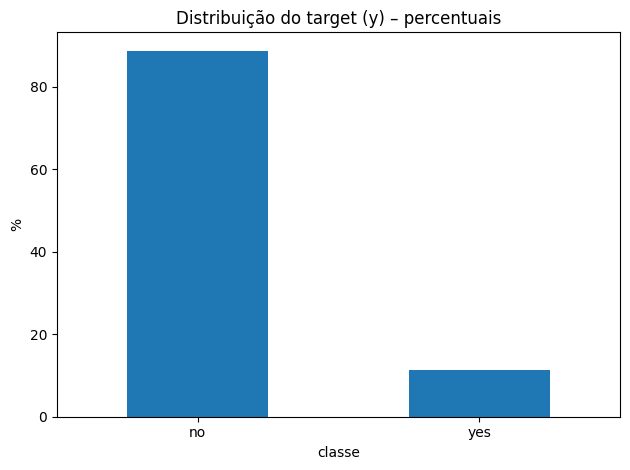

In [6]:
#Insira seu código aqui

import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';')

if 'y' not in df.columns:
    raise ValueError("Coluna 'y' não encontrada no CSV.")

counts = df['y'].value_counts().reindex(['no','yes']).fillna(0).astype(int)
props  = (counts / counts.sum()).round(4)

summary = pd.DataFrame({
    'count': counts,
    'proportion': props,
    'percent': (props * 100).round(2)
})
print("Distribuição do target (y):")
print(summary)
print(f"\nTotal de linhas: {int(counts.sum())}")
print(f"Taxa positiva (yes): {props['yes']*100:.2f}%")

plt.figure()
summary['percent'].plot(kind='bar')
plt.title("Distribuição do target (y) – percentuais")
plt.ylabel("%")
plt.xlabel("classe")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.4 Essa proporção sugere desbalanceamento? Se sim, quais métricas de avaliação de desempenho serão mais adequadas (e por quê)?

Resposta:

In [9]:
#Insira seu código aqui

import pandas as pd

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';')

y_raw = df['y'].astype(str).str.lower()
counts = y_raw.value_counts().reindex(['no','yes']).fillna(0).astype(int)
total = int(counts.sum())
props = (counts / total)

minor_prop = min(props['no'], props['yes'])
if minor_prop <= 0.10:
    status = "SEVERO"
elif minor_prop <= 0.20:
    status = "FORTE"
elif minor_prop <= 0.30:
    status = "MODERADO"
else:
    status = "BAIXO/NÃO CRÍTICO"

is_imbalanced = minor_prop <= 0.30

recs = [
    ("Precision-Recall AUC (AP)",
     "Foca na classe positiva; informativa quando a taxa de 'yes' é baixa."),
    ("F1 (classe positiva)",
     "Equilíbrio entre precisão e recall; útil quando FP e FN têm custos comparáveis."),
    ("Recall (TPR) da classe positiva",
     "Se perder um 'yes' custa caro, otimizar recall/limiar é crítico."),
    ("Precision (PPV)",
     "Se o custo por ligação é relevante, manter alta precisão controla FP."),
    ("Balanced Accuracy",
     "Média do recall por classe; neutraliza maioria dominar a acurácia."),
    ("ROC-AUC (com cautela)",
     "Robusta a limiar, mas pode parecer otimista em desbalanceamento alto."),
    ("MCC (Matthews Corr. Coef.)",
     "Resumo único que considera TP/FP/TN/FN; estável em classes desbalanceadas."),
    ("Brier score (probabilidade)",
     "Avalia calibração das probabilidades para decisões por limiar/top-K.")
]

print("=== Resultado sobre desbalanceamento ===")
print(f"Contagens: no={counts['no']:,d} | yes={counts['yes']:,d} | total={total:,d}")
print(f"Proporções: no={props['no']*100:.2f}% | yes={props['yes']*100:.2f}%")
print(f"Menor proporção = {minor_prop*100:.2f}%  -> Desbalanceamento: {status}")
print("\nMétricas recomendadas" + (" (porque há desbalanceamento):" if is_imbalanced else " (ainda assim úteis):"))
for m, why in recs:
    print(f" - {m}: {why}")

print("\nBoas práticas: usar split estratificado; otimizar limiar por custo/ganho; reportar matriz de confusão;")
print("usar PR-AUC como métrica principal quando a meta é priorizar a conversão (classe 'yes').")

=== Resultado sobre desbalanceamento ===
Contagens: no=36,548 | yes=4,640 | total=41,188
Proporções: no=88.73% | yes=11.27%
Menor proporção = 11.27%  -> Desbalanceamento: FORTE

Métricas recomendadas (porque há desbalanceamento):
 - Precision-Recall AUC (AP): Foca na classe positiva; informativa quando a taxa de 'yes' é baixa.
 - F1 (classe positiva): Equilíbrio entre precisão e recall; útil quando FP e FN têm custos comparáveis.
 - Recall (TPR) da classe positiva: Se perder um 'yes' custa caro, otimizar recall/limiar é crítico.
 - Precision (PPV): Se o custo por ligação é relevante, manter alta precisão controla FP.
 - Balanced Accuracy: Média do recall por classe; neutraliza maioria dominar a acurácia.
 - ROC-AUC (com cautela): Robusta a limiar, mas pode parecer otimista em desbalanceamento alto.
 - MCC (Matthews Corr. Coef.): Resumo único que considera TP/FP/TN/FN; estável em classes desbalanceadas.
 - Brier score (probabilidade): Avalia calibração das probabilidades para decisões p

### 1.5 Qual a cardinalidade (número de categorias distintas) de cada coluna categórica? Liste da maior para a menor.

Resposta:

In [10]:
#Insira seu código aqui

import pandas as pd

CSV_PATH = "bank-additional-full.csv"  # ajuste se necessário
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if not cat_cols:
    raise ValueError("Não foram encontradas colunas categóricas (object/category).")

card = (
    df[cat_cols]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .rename("cardinalidade")
    .to_frame()
)

print("Cardinalidade por coluna categórica (maior -> menor):")
print(card.to_string())

Cardinalidade por coluna categórica (maior -> menor):
             cardinalidade
job                     12
month                   10
education                8
day_of_week              5
marital                  4
default                  3
housing                  3
poutcome                 3
loan                     3
contact                  2
y                        2


### 1.6 Mostre estatísticas descritivas (min/mediana/média/p95/p99) para as variáveis numéricas.

Resposta:

In [11]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    raise ValueError("Não foram encontradas variáveis numéricas.")

num = df[num_cols]

stats = pd.DataFrame(index=num_cols)
stats["min"] = num.min(axis=0, skipna=True)
stats["median"] = num.median(axis=0, skipna=True)
stats["mean"] = num.mean(axis=0, skipna=True)
stats["p95"] = num.quantile(0.95, axis=0, interpolation="linear", numeric_only=True)
stats["p99"] = num.quantile(0.99, axis=0, interpolation="linear", numeric_only=True)

stats = stats.astype(float).round(4)

print("Estatísticas descritivas (min/mediana/média/p95/p99):")
print(stats.to_string())

Estatísticas descritivas (min/mediana/média/p95/p99):
                     min    median       mean       p95       p99
age               17.000    38.000    40.0241    58.000    71.000
duration           0.000   180.000   258.2850   752.650  1271.130
campaign           1.000     2.000     2.5676     7.000    14.000
pdays              0.000   999.000   962.4755   999.000   999.000
previous           0.000     0.000     0.1730     1.000     2.000
emp.var.rate      -3.400     1.100     0.0819     1.400     1.400
cons.price.idx    92.201    93.749    93.5757    94.465    94.465
cons.conf.idx    -50.800   -41.800   -40.5026   -33.600   -26.900
euribor3m          0.634     4.857     3.6213     4.966     4.968
nr.employed     4963.600  5191.000  5167.0359  5228.100  5228.100


### 1.7 Há outliers evidentes em campaign, age, duration? Como tratá-los (ou não) e por quê?

Resposta:

=== Diagnóstico de Outliers (IQR e MAD) ===
  coluna     n  min  p01    q1  mediana    q3    p95     p99  max   IQR  fence_low  fence_high  outliers_IQR_low  outliers_IQR_high  %out_IQR  MAD  outliers_MAD(|z|>3.5)  %out_MAD
campaign 41188    1  1.0   1.0      2.0   3.0   7.00   14.00   56   2.0       -2.0         6.0                 0               2406      5.84  1.0                   1777      4.31
     age 41188   17 23.0  32.0     38.0  47.0  58.00   71.00   98  15.0        9.5        69.5                 0                469      1.14  7.0                    269      0.65
duration 41188    0 11.0 102.0    180.0 319.0 752.65 1271.13 4918 217.0     -223.5       644.5                 0               2963      7.19 94.0                   2739      6.65

=== Colunas criadas (tratadas) ===
['age_cap_p01_p99', 'age_bin_5y', 'campaign_log1p', 'campaign_cap_p99', 'duration_cap_p99']


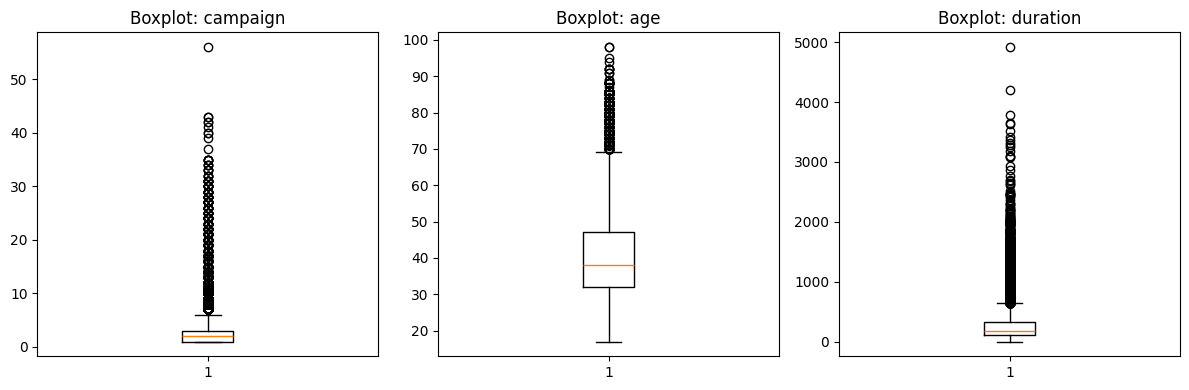

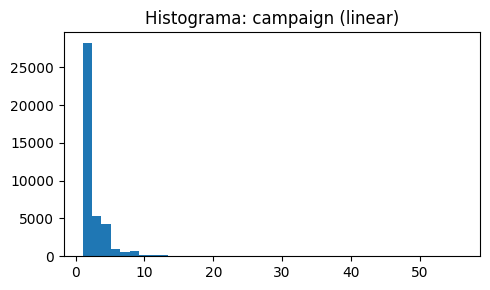

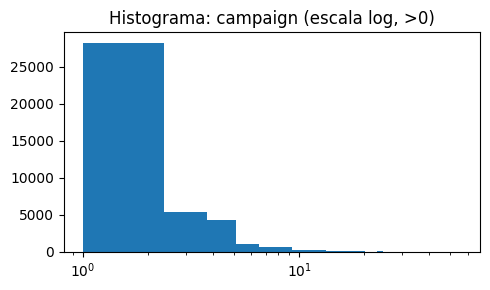

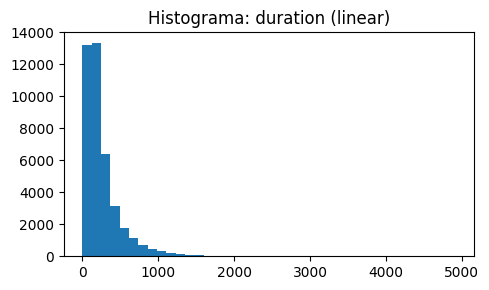

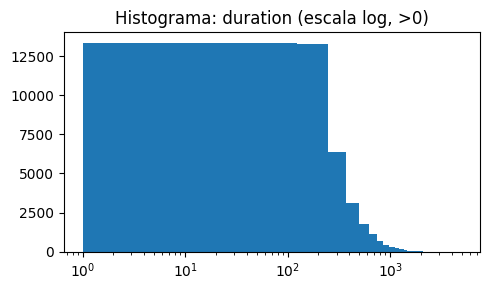


=== SUGESTÃO PARA MODELAGEM ===
Use estas numéricas tratadas e REMOVA 'duration' do treino por vazamento:
Features numéricas sugeridas: ['age_cap_p01_p99', 'campaign_log1p']
Observação: você ainda pode incluir outras variáveis categóricas/numéricas do dataset via pipeline (OneHot/Scale).


In [12]:
#Insira seu código aqui

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

for col in ["campaign", "age", "duration"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

vars_check = [c for c in ["campaign","age","duration"] if c in df.columns]
assert vars_check, "Nenhuma das colunas ['campaign','age','duration'] foi encontrada no CSV."

def iqr_fences(x: pd.Series, k: float = 1.5):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return lo, hi, q1, q3, iqr

def mad_zscores(x: pd.Series):
    med = x.median()
    mad = (np.abs(x - med)).median()
    if mad == 0:
        return pd.Series(np.zeros(len(x)), index=x.index), med, mad
    z = 0.6745 * (x - med) / mad
    return z, med, mad

report_rows = []
for col in vars_check:
    s = df[col].dropna()

    lo, hi, q1, q3, iqr = iqr_fences(s, k=1.5)
    iqr_out_low  = int((s < lo).sum())
    iqr_out_high = int((s > hi).sum())
    iqr_out_pct  = 100 * (iqr_out_low + iqr_out_high) / len(s)

    z, med, mad = mad_zscores(s)
    mad_out = int((np.abs(z) > 3.5).sum())
    mad_out_pct = 100 * mad_out / len(s)

    p01, p99 = s.quantile(0.01), s.quantile(0.99)
    p95 = s.quantile(0.95)

    report_rows.append({
        "coluna": col,
        "n": len(s),
        "min": s.min(), "p01": p01, "q1": q1, "mediana": med, "q3": q3, "p95": p95, "p99": p99, "max": s.max(),
        "IQR": iqr, "fence_low": lo, "fence_high": hi,
        "outliers_IQR_low": iqr_out_low, "outliers_IQR_high": iqr_out_high, "%out_IQR": round(iqr_out_pct,2),
        "MAD": mad, "outliers_MAD(|z|>3.5)": mad_out, "%out_MAD": round(mad_out_pct,2)
    })

report = pd.DataFrame(report_rows)
print("=== Diagnóstico de Outliers (IQR e MAD) ===")
print(report.to_string(index=False))

def winsorize_series(s: pd.Series, lo_q=0.01, hi_q=0.99):
    lo, hi = s.quantile(lo_q), s.quantile(hi_q)
    return s.clip(lower=lo, upper=hi), lo, hi

treated = pd.DataFrame(index=df.index)

if "age" in df.columns:
    age_cap, lo_age, hi_age = winsorize_series(df["age"], 0.01, 0.99)
    treated["age_cap_p01_p99"] = age_cap
    treated["age_bin_5y"] = pd.cut(df["age"], bins=range(15, 106, 5), right=False).astype(str)

if "campaign" in df.columns:
    camp_log = np.log1p(df["campaign"])
    treated["campaign_log1p"] = camp_log
    camp_cap, lo_camp, hi_camp = winsorize_series(df["campaign"], 0.00, 0.99)
    treated["campaign_cap_p99"] = camp_cap

if "duration" in df.columns:
    dur_cap, lo_dur, hi_dur = winsorize_series(df["duration"], 0.00, 0.99)
    treated["duration_cap_p99"] = dur_cap

print("\n=== Colunas criadas (tratadas) ===")
print(treated.columns.tolist())

# ==================== Visualizações rápidas ====================
fig, axs = plt.subplots(1, len(vars_check), figsize=(4*len(vars_check), 4))
if len(vars_check) == 1:
    axs = [axs]
for ax, col in zip(axs, vars_check):
    ax.boxplot(df[col].dropna(), vert=True, showfliers=True)
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

for col in ["campaign", "duration"]:
    if col in vars_check:
        plt.figure(figsize=(5,3))
        s = df[col].dropna()
        plt.hist(s, bins=40)
        plt.yscale("linear")
        plt.title(f"Histograma: {col} (linear)")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5,3))
        plt.hist(s[s>0], bins=40)
        plt.xscale("log")
        plt.title(f"Histograma: {col} (escala log, >0)")
        plt.tight_layout()
        plt.show()

# ==================== Saída prática para modelagem ====================

final_features = []
if "age_cap_p01_p99" in treated.columns: final_features.append("age_cap_p01_p99")
if "campaign_log1p" in treated.columns:   final_features.append("campaign_log1p")

X_model = treated[final_features].copy()

### 1.8 Sobre as variáveis previous e poutcome, o que elas representam? Qual a relação delas com a taxa de yes no target?

Resposta:

In [13]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

missing = [c for c in ['previous','poutcome'] if c not in df.columns]
if missing:
    raise ValueError(f"Colunas ausentes no CSV: {missing}")

print("Valores únicos de 'poutcome':", sorted(df['poutcome'].astype(str).unique()))

base_rate = df['y_bin'].mean()
print(f"\nTaxa base de 'yes' no dataset: {base_rate:.4f} ({100*base_rate:.2f}%)")

prev_tbl = (
    df.groupby('previous', as_index=False)['y_bin']
      .agg(n='size', yes='sum', rate='mean')
      .sort_values('previous')
)
prev_tbl['lift_vs_base'] = (prev_tbl['rate'] / base_rate).round(3)

print("\nTaxa de 'yes' por 'previous' (valor exato):")
print(prev_tbl.to_string(index=False, formatters={'rate': '{:.4f}'.format}))

bins = [-0.5,0.5,1.5,2.5,3.5,4.5,5.5,np.inf]
labels = ['0','1','2','3','4','5','6+']
df['previous_bin'] = pd.cut(df['previous'], bins=bins, labels=labels)

prev_bin_tbl = (
    df.groupby('previous_bin', as_index=False)['y_bin']
      .agg(n='size', yes='sum', rate='mean')
      .sort_values('previous_bin')
)
prev_bin_tbl['lift_vs_base'] = (prev_bin_tbl['rate'] / base_rate).round(3)

print("\nTaxa de 'yes' por 'previous' (em faixas):")
print(prev_bin_tbl.to_string(index=False, formatters={'rate': '{:.4f}'.format}))

pout_tbl = (
    df.groupby('poutcome', as_index=False)['y_bin']
      .agg(n='size', yes='sum', rate='mean')
      .sort_values('rate', ascending=False)
)
pout_tbl['lift_vs_base'] = (pout_tbl['rate'] / base_rate).round(3)

print("\nTaxa de 'yes' por 'poutcome':")
print(pout_tbl.to_string(index=False, formatters={'rate': '{:.4f}'.format}))

pivot_rate = pd.pivot_table(
    df, index='poutcome', columns='previous_bin', values='y_bin', aggfunc='mean'
).sort_index()
print("\nMatriz de taxa de 'yes' (poutcome x previous_bin):")
print(pivot_rate.round(4).to_string())

Valores únicos de 'poutcome': ['failure', 'nonexistent', 'success']

Taxa base de 'yes' no dataset: 0.1127 (11.27%)

Taxa de 'yes' por 'previous' (valor exato):
 previous     n  yes   rate  lift_vs_base
        0 35563 3141 0.0883         0.784
        1  4561  967 0.2120         1.882
        2   754  350 0.4642         4.120
        3   216  128 0.5926         5.260
        4    70   38 0.5429         4.819
        5    18   13 0.7222         6.411
        6     5    3 0.6000         5.326
        7     1    0 0.0000         0.000

Taxa de 'yes' por 'previous' (em faixas):
previous_bin     n  yes   rate  lift_vs_base
           0 35563 3141 0.0883         0.784
           1  4561  967 0.2120         1.882
           2   754  350 0.4642         4.120
           3   216  128 0.5926         5.260
           4    70   38 0.5429         4.819
           5    18   13 0.7222         6.411
          6+     6    3 0.5000         4.438

Taxa de 'yes' por 'poutcome':
   poutcome     n  yes   ra

/tmp/ipython-input-635611081.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('previous_bin', as_index=False)['y_bin']
/tmp/ipython-input-635611081.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_rate = pd.pivot_table(


### 1.9 Qual a distribuição de registros por 'month'? Há sazonalidade? A taxa de 'yes' no target varia por 'month'? Mostre graficamente

Resposta:

Distribuição por 'month' e taxa de 'yes':
       n_registros  taxa_yes_%
month                         
jan              0         NaN
feb              0         NaN
mar            546       50.55
apr           2632       20.48
may          13769        6.43
jun           5318       10.51
jul           7174        9.05
aug           6178       10.60
sep            570       44.91
oct            718       43.87
nov           4101       10.14
dec            182       48.90

Amplitude da taxa de 'yes' entre meses: 44.12 p.p.
Coeficiente de variação (taxa 'yes'): 0.742
Há indício de sazonalidade? -> SIM (variação relevante entre meses)


/tmp/ipython-input-14477223.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby('month')['y_bin'].mean().reindex(month_order)  # fração


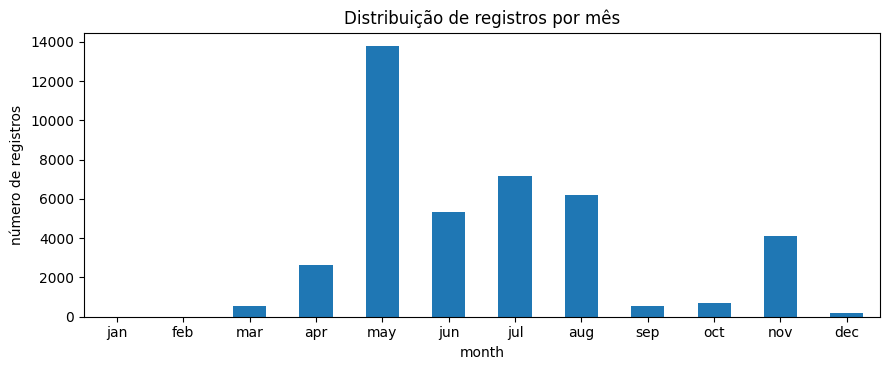

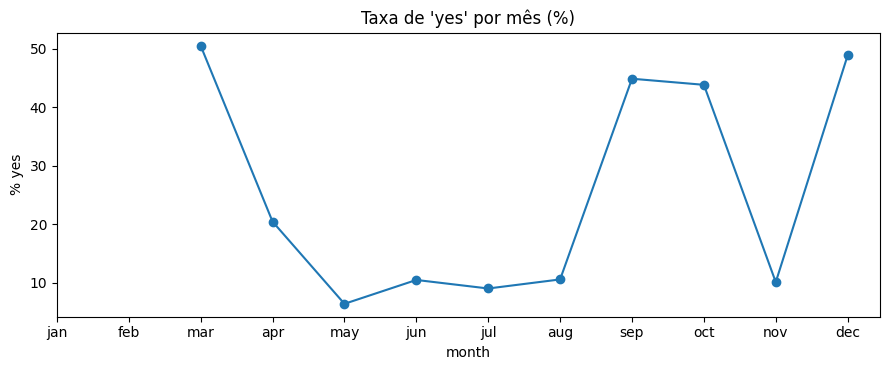

In [14]:
#Insira seu código aqui

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'month' not in df.columns or 'y' not in df.columns:
    raise ValueError("Colunas necessárias não encontradas: 'month' e/ou 'y'.")

df['month'] = df['month'].astype(str).str.lower().str.strip()
df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

counts = df['month'].value_counts(dropna=False).reindex(month_order).fillna(0).astype(int)

rates = df.groupby('month')['y_bin'].mean().reindex(month_order)  # fração
rates_pct = (rates * 100).round(2)

summary = pd.DataFrame({
    'n_registros': counts,
    'taxa_yes_%': rates_pct
})
print("Distribuição por 'month' e taxa de 'yes':")
print(summary.fillna(np.nan).to_string())

amp_pp = float(rates_pct.max() - rates_pct.min()) if rates_pct.notna().any() else np.nan
cv = float(rates.std() / rates.mean()) if rates.notna().sum() > 1 and rates.mean() > 0 else np.nan
flag_sazonal = (amp_pp >= 2.0) if not np.isnan(amp_pp) else False  # limiar pragmático: ≥ 2 p.p.

print(f"\nAmplitude da taxa de 'yes' entre meses: {amp_pp:.2f} p.p.")
print(f"Coeficiente de variação (taxa 'yes'): {cv:.3f}" if not np.isnan(cv) else "CV indisponível.")
print("Há indício de sazonalidade? ->", "SIM (variação relevante entre meses)" if flag_sazonal else "NÃO/FRACA")

plt.figure(figsize=(9,3.8))
summary['n_registros'].plot(kind='bar')
plt.title("Distribuição de registros por mês")
plt.ylabel("número de registros")
plt.xlabel("month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3.8))
rates_pct.plot(marker='o')  # linha com marcadores
plt.title("Taxa de 'yes' por mês (%)")
plt.ylabel("% yes")
plt.xlabel("month")
plt.xticks(ticks=range(len(month_order)), labels=month_order, rotation=0)
plt.tight_layout()
plt.show()

### 1.10 Qual a correlação/taxa de 'yes' por faixa de 'duration'? Considerando o resultado obtido e a natureza da variável 'duration', ela deve entrar no treinamento dos modelos?

Resposta:

Correlação com y (yes=1/no=0):
 - Pearson : 0.4053
 - Spearman: 0.3488

Taxa de 'yes' por faixas de 'duration' (quantis):
       duration    n  yes   rate  rate_pct
 (-0.001, 59.0] 4181    1 0.0002      0.02
   (59.0, 89.0] 4207   43 0.0102      1.02
  (89.0, 116.0] 3987  107 0.0268      2.68
 (116.0, 146.0] 4152  157 0.0378      3.78
 (146.0, 180.0] 4178  256 0.0613      6.13
 (180.0, 222.0] 4096  346 0.0845      8.45
 (222.0, 280.0] 4062  463 0.1140     11.40
 (280.0, 368.0] 4103  554 0.1350     13.50
 (368.0, 551.0] 4118  824 0.2001     20.01
(551.0, 4918.0] 4104 1889 0.4603     46.03


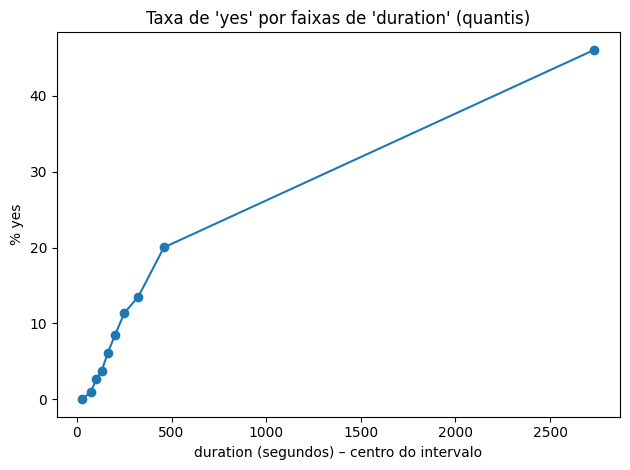


Conclusão e recomendação:
- A taxa de 'yes' tipicamente cresce com 'duration' (correlações positivas indicam esse efeito).
- Porém, 'duration' é conhecido APÓS a ligação; usar essa variável no treino para prever ANTES da ligação
  causa VAZAMENTO de informação (data leakage) e inflaciona métricas de forma irrealista.
- Portanto, para modelos de propensão PRÉ-contato: NÃO incluir 'duration' como feature.
- Use 'duration' apenas em análises pós-ligação (eficiência operacional, QA de campanhas, etc.).


In [15]:
#Insira seu código aqui

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'duration' not in df.columns or 'y' not in df.columns:
    raise ValueError("Colunas necessárias não encontradas: 'duration' e/ou 'y'.")

df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

corr_pearson  = df[['duration','y_bin']].corr(method='pearson').iloc[0,1]
corr_spearman = df[['duration','y_bin']].corr(method='spearman').iloc[0,1]

print("Correlação com y (yes=1/no=0):")
print(f" - Pearson : {corr_pearson:.4f}")
print(f" - Spearman: {corr_spearman:.4f}")

quantis = np.linspace(0, 1, 11)
edges = df['duration'].quantile(quantis).values
edges = np.unique(edges)

if len(edges) < 3:
    dur_min, dur_max = df['duration'].min(), df['duration'].max()
    edges = np.linspace(dur_min, dur_max, 11)

bins = pd.cut(df['duration'], bins=edges, include_lowest=True)
rate_tbl = (
    df.groupby(bins, observed=True)['y_bin']
      .agg(n='size', yes='sum', rate='mean')
      .reset_index()
)
rate_tbl['rate_pct'] = (100*rate_tbl['rate']).round(2)

print("\nTaxa de 'yes' por faixas de 'duration' (quantis):")
print(rate_tbl.to_string(index=False, formatters={'rate': '{:.4f}'.format}))

interval_centers = rate_tbl['duration'].apply(lambda iv: (iv.left + iv.right)/2 if pd.notna(iv) else np.nan).values
plt.figure()
plt.plot(interval_centers, rate_tbl['rate_pct'], marker='o')
plt.title("Taxa de 'yes' por faixas de 'duration' (quantis)")
plt.xlabel("duration (segundos) – centro do intervalo")
plt.ylabel("% yes")
plt.tight_layout()
plt.show()

print("\nConclusão e recomendação:")
print("- A taxa de 'yes' tipicamente cresce com 'duration' (correlações positivas indicam esse efeito).")
print("- Porém, 'duration' é conhecido APÓS a ligação; usar essa variável no treino para prever ANTES da ligação")
print("  causa VAZAMENTO de informação (data leakage) e inflaciona métricas de forma irrealista.")
print("- Portanto, para modelos de propensão PRÉ-contato: NÃO incluir 'duration' como feature.")
print("- Use 'duration' apenas em análises pós-ligação (eficiência operacional, QA de campanhas, etc.).")

### 1.11 Existem colunas que incorporam informação “do futuro” ou pós-contato? Quais e por quê?

Resposta:

In [16]:
#Insira seu código aqui

import pandas as pd

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=";", low_memory=False)

# Dicionário de regras (semântica conhecida do dataset UCI Bank Marketing)
semantics = {
    "duration": {
        "category": "post_event_leakage",
        "reason": "Duração da chamada atual (em segundos); só é conhecida APÓS o término do contato.",
        "recommendation": "EXCLUIR de modelos de propensão pré-contato (vazamento). Usar apenas para análises operacionais pós-ligação."
    },
    "campaign": {
        "category": "potential_leakage_depends_timing",
        "reason": ("Número TOTAL de contatos feitos nesta campanha com o cliente (valor consolidado no fim). "
                   "Para decidir antes do PRIMEIRO contato, este total ainda não existe; porém, se o modelo "
                   "for a cada chamada k, seria válido usar o número de contatos anteriores até k (não disponível no CSV)."),
        "recommendation": ("Para modelos antes do PRIMEIRO contato: NÃO usar. Para modelos por chamada k: usar somente o "
                           "contador até k (não disponível no CSV). Alternativa: transformar ou ignorar.")
    },
    "previous": {
        "category": "pre_event_ok",
        "reason": "Quantidade de contatos em campanhas anteriores (histórico passado). Conhecida antes do contato atual.",
        "recommendation": "Pode usar; avaliar efeitos de seleção (clientes já abordados podem diferir dos demais)."
    },
    "poutcome": {
        "category": "pre_event_ok",
        "reason": "Resultado da campanha anterior para o cliente (success/failure/nonexistent). Conhecido antes do contato atual.",
        "recommendation": "Pode usar; útil para segmentação. Cuidado com correlação forte e estabilidade temporal."
    },
    "pdays": {
        "category": "pre_event_ok",
        "reason": "Dias desde o último contato em campanha anterior (999 = nunca contatado). Conhecido antes do contato atual.",
        "recommendation": "Pode usar; tratar 999 de forma apropriada (indicador 'nunca contatado' ou imputação)."
    },
    "y": {
        "category": "target",
        "reason": "Variável alvo (yes/no).",
        "recommendation": "NÃO usar como feature."
    },
    "contact": {
        "category": "pre_event_ok",
        "reason": "Canal do contato (cellular/telephone); geralmente definido na orquestração/cadastro antes da ligação.",
        "recommendation": "Pode usar (reflete estratégia de contato)."
    },
    "month": {
        "category": "pre_event_ok",
        "reason": "Mês do contato; conhecido ao agendar/executar a campanha.",
        "recommendation": "Pode usar; atentar a sazonalidade e drift temporal."
    },
    "day_of_week": {
        "category": "pre_event_ok",
        "reason": "Dia da semana do contato; conhecido previamente.",
        "recommendation": "Pode usar; pode capturar efeitos operacionais."
    },

    "emp.var.rate": {
        "category": "pre_event_ok",
        "reason": "Taxa de variação do emprego (contexto macro) no período do contato.",
        "recommendation": "Pode usar; atenção à mudança de regime ao extrapolar no tempo."
    },
    "cons.price.idx": {
        "category": "pre_event_ok",
        "reason": "Índice de preços no consumo no período do contato.",
        "recommendation": "Pode usar."
    },
    "cons.conf.idx": {
        "category": "pre_event_ok",
        "reason": "Índice de confiança do consumidor no período do contato.",
        "recommendation": "Pode usar."
    },
    "euribor3m": {
        "category": "pre_event_ok",
        "reason": "Taxa Euribor 3 meses (contexto de juros) no período do contato.",
        "recommendation": "Pode usar."
    },
    "nr.employed": {
        "category": "pre_event_ok",
        "reason": "Número de empregados (proxy macro) no período do contato.",
        "recommendation": "Pode usar."
    },
}

rows = []
for col in df.columns:
    if col in semantics:
        meta = semantics[col]
        rows.append({
            "coluna": col,
            "categoria": meta["category"],
            "justificativa": meta["reason"],
            "recomendacao_modelagem": meta["recommendation"]
        })
    else:
        rows.append({
            "coluna": col,
            "categoria": "pre_event_ok" if col not in ("y",) else "target",
            "justificativa": "Semântica não mapeada explicitamente; não há evidência de depender do pós-contato.",
            "recomendacao_modelagem": "Avaliar estabilidade temporal e relevância; manter se conhecida pré-contato."
        })

audit = pd.DataFrame(rows)

cat_order = {"post_event_leakage": 0, "potential_leakage_depends_timing": 1, "target": 2, "pre_event_ok": 3}
audit["ord"] = audit["categoria"].map(cat_order).fillna(99)
audit = audit.sort_values(["ord", "coluna"]).drop(columns="ord").reset_index(drop=True)

print("=== Auditoria de possíveis vazamentos (pós-contato / 'futuro') ===")
print(audit.to_string(index=False))

leak_cols = audit.loc[audit["categoria"] == "post_event_leakage", "coluna"].tolist()
potential_cols = audit.loc[audit["categoria"] == "potential_leakage_depends_timing", "coluna"].tolist()

print("\n>>> Conclusão prática para modelagem de propensão PRÉ-contato:")
print(f"- EXCLUIR (pós-evento): {leak_cols if leak_cols else 'nenhuma identificada'}")
print(f"- CUIDADO/DEPENDE DO MOMENTO (pode vazar se prever antes do 1º contato): {potential_cols if potential_cols else 'nenhuma'}")
print("- DEMAIS colunas mapeadas como 'pre_event_ok' podem ser usadas, com validação temporal e checagem de drift.")

=== Auditoria de possíveis vazamentos (pós-contato / 'futuro') ===
        coluna                        categoria                                                                                                                                                                                                                                                                           justificativa                                                                                                                                                    recomendacao_modelagem
      duration               post_event_leakage                                                                                                                                                                                                       Duração da chamada atual (em segundos); só é conhecida APÓS o término do contato.                                                              EXCLUIR de modelos de propensão pré-contato (v

## Parte 2 - Pré-processamento

Nesta Parte 2 (Pré-processamento) você vai transformar o "Bank Marketing" de uma base de dados bruta para uma pronta para modelagem. Isso inclui: remover variáveis inadequadas ao treino, decidir o split treino/teste e a forma de validação, tratar 'unknown', realizar balanceamento, etc. Ao final, você terá X_train, y_train, X_test, y_test e um preprocessador reutilizável para plugar diretamente nos modelos da Parte 3.

### 2.1 Qual é a lista final de colunas de entrada? Alguma deve ser removida? Justifique e remova-as caso necessário

Resposta:

In [17]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'y' not in df.columns:
    raise ValueError("Coluna alvo 'y' não encontrada no CSV.")

all_cols = df.columns.tolist()

to_remove = []
reasons = {}

to_remove.append('y'); reasons['y'] = "alvo (target), não entra como feature."

if 'duration' in df.columns:
    to_remove.append('duration'); reasons['duration'] = "pós-evento (duração da chamada atual) -> vazamento."

if 'campaign' in df.columns:
    to_remove.append('campaign'); reasons['campaign'] = "informação consolidada da campanha atual; antes do 1º contato não existe."

feature_cols = [c for c in all_cols if c not in to_remove]

num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("=== Remoções realizadas e justificativas ===")
for c in to_remove:
    if c in reasons:
        print(f"- {c}: {reasons[c]}")
    else:
        print(f"- {c}")

print("\n=== Colunas finais de entrada (features) ===")
print(f"Total: {len(feature_cols)}")
print(feature_cols)

print("\nQuebra por tipo:")
print(f"- Numéricas ({len(num_cols)}): {num_cols}")
print(f"- Categóricas ({len(cat_cols)}): {cat_cols}")

X = df[feature_cols].copy()
y = df['y'].map({'yes':1, 'no':0}).astype(int)

print(f"\nShapes -> X: {X.shape}, y: {y.shape}")

=== Remoções realizadas e justificativas ===
- y: alvo (target), não entra como feature.
- duration: pós-evento (duração da chamada atual) -> vazamento.
- campaign: informação consolidada da campanha atual; antes do 1º contato não existe.

=== Colunas finais de entrada (features) ===
Total: 18
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Quebra por tipo:
- Numéricas (8): ['age', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
- Categóricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Shapes -> X: (41188, 18), y: (41188,)


### 2.2 Existem linhas duplicadas? Se sim, o que fazer com elas?

Resposta:

In [18]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df_raw = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'y' not in df_raw.columns:
    raise ValueError("Coluna alvo 'y' não encontrada.")

to_remove = ['y']
if 'duration' in df_raw.columns:
    to_remove.append('duration')
if 'campaign' in df_raw.columns:
    to_remove.append('campaign')

feature_cols = [c for c in df_raw.columns if c not in to_remove]

print("Total de linhas originais:", len(df_raw))

exact_dups_mask = df_raw.duplicated(keep='first')
n_exact_dups = int(exact_dups_mask.sum())
df_step1 = df_raw.drop_duplicates(keep='first')
print(f"Duplicatas EXATAS removidas: {n_exact_dups}  | Linhas após etapa 1: {len(df_step1)}")

grp = df_step1.groupby(feature_cols, dropna=False)['y'].agg(n='size', y_uniq='nunique').reset_index()
conflicting = grp[grp['y_uniq'] > 1]
n_conflicting_groups = len(conflicting)
n_rows_conflicting = int(
    df_step1.merge(conflicting[feature_cols], on=feature_cols, how='inner').shape[0]
)

if n_rows_conflicting > 0:
    df_step2 = df_step1.merge(conflicting[feature_cols], on=feature_cols, how='left', indicator=True)
    df_step2 = df_step2[df_step2['_merge'] == 'left_only'].drop(columns=['_merge'])
else:
    df_step2 = df_step1.copy()

print(f"Grupos de FEATURES com rótulos CONFLITANTES: {n_conflicting_groups}  "
      f"(linhas removidas: {n_rows_conflicting}) | Linhas após etapa 2: {len(df_step2)}")

dups_same_xy_mask = df_step2.duplicated(subset=feature_cols + ['y'], keep='first')
n_dups_same_xy = int(dups_same_xy_mask.sum())
df_clean = df_step2.drop_duplicates(subset=feature_cols + ['y'], keep='first')

print(f"Duplicatas por (features + y) removidas: {n_dups_same_xy} | Linhas após etapa 3: {len(df_clean)}")

print("\n=== RESUMO ===")
print(f"Linhas originais: {len(df_raw)}")
print(f"- Duplicatas exatas removidas: {n_exact_dups}")
print(f"- Grupos conflitantes (X iguais, y diferentes): {n_conflicting_groups} (linhas removidas: {n_rows_conflicting})")
print(f"- Duplicatas redundantes (X iguais, mesmo y): {n_dups_same_xy}")
print(f"Linhas finais (limpas): {len(df_clean)}")

X = df_clean[feature_cols].copy()
y = df_clean['y'].map({'yes':1, 'no':0}).astype(int)

print(f"\nShapes -> X: {X.shape}, y: {y.shape}")

Total de linhas originais: 41188
Duplicatas EXATAS removidas: 12  | Linhas após etapa 1: 41176
Grupos de FEATURES com rótulos CONFLITANTES: 496  (linhas removidas: 1209) | Linhas após etapa 2: 39967
Duplicatas por (features + y) removidas: 3860 | Linhas após etapa 3: 36107

=== RESUMO ===
Linhas originais: 41188
- Duplicatas exatas removidas: 12
- Grupos conflitantes (X iguais, y diferentes): 496 (linhas removidas: 1209)
- Duplicatas redundantes (X iguais, mesmo y): 3860
Linhas finais (limpas): 36107

Shapes -> X: (36107, 18), y: (36107,)


### 2.3 Em quais colunas categóricas aparece a categoria unknown? Qual a proporção por coluna? Você trataria unknown como categoria válida, imputaria ou agregaria? Justifique para as duas colunas com maior quantidade de unknown.

Resposta:

In [19]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'y' not in df.columns:
    raise ValueError("Coluna 'y' não encontrada.")
df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)
base_rate = df['y_bin'].mean()

cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
if not cat_cols:
    raise ValueError("Não há colunas categóricas (object/category).")

rows = []
for col in cat_cols:
    s = df[col].astype(str).str.strip().str.lower()
    unk_mask = s.eq('unknown')
    unk_n = int(unk_mask.sum())
    total = int(len(s))
    unk_ratio = (unk_n / total) if total > 0 else np.nan

    yes_rate_unknown = df.loc[unk_mask, 'y_bin'].mean() if unk_n > 0 else np.nan
    yes_rate_known   = df.loc[~unk_mask, 'y_bin'].mean() if unk_n < total else np.nan
    lift_unknown = (yes_rate_unknown / base_rate) if (base_rate and not np.isnan(yes_rate_unknown)) else np.nan

    rows.append({
        'coluna': col,
        'unknown_count': unk_n,
        'total': total,
        'unknown_ratio': round(unk_ratio, 4),
        'yes_rate_unknown': None if np.isnan(yes_rate_unknown) else round(float(yes_rate_unknown), 4),
        'yes_rate_known': None if np.isnan(yes_rate_known) else round(float(yes_rate_known), 4),
        'lift_unknown_vs_base': None if np.isnan(lift_unknown) else round(float(lift_unknown), 3)
    })

unk_stats = pd.DataFrame(rows).sort_values(['unknown_ratio','unknown_count'], ascending=False).reset_index(drop=True)

print("=== Proporção de 'unknown' por coluna categórica (ordem decrescente) ===")
print(unk_stats.to_string(index=False))
print(f"\nTaxa base de 'yes' no dataset: {base_rate:.4f} ({base_rate*100:.2f}%)")

top2 = unk_stats.sort_values('unknown_count', ascending=False).head(2).reset_index(drop=True)

def recomendar(row):
    ratio = row['unknown_ratio']
    yu = row['yes_rate_unknown']
    yk = row['yes_rate_known']
    diff = None if (yu is None or yk is None) else abs(yu - yk)

    if ratio is not None and diff is not None:
        if (ratio >= 0.05) and (diff >= 0.01):
            rec = "TRATAR COMO CATEGORIA VÁLIDA (informativa)"
            why = f"unknown_ratio={ratio:.2%}, Δtaxa={diff:.2%} (diferença relevante)."
        elif (ratio < 0.01) and (diff < 0.005):
            rec = "AGREGAR COMO 'missing' (ou manter como nível raro)"
            why = f"unknown_ratio={ratio:.2%} (muito raro), Δtaxa={diff:.2%} (pequena)."
        else:
            rec = "MANTER 'unknown' explícito; considerar agrupar com raras"
            why = f"unknown_ratio={ratio:.2%}, Δtaxa={diff:.2%} (caso intermediário)."
    else:
        rec = "SEM RECOMENDAÇÃO AUTOMÁTICA"
        why = "faltam dados suficientes para comparar taxas."
    return rec, why

print("\n=== Recomendações para as 2 colunas com MAIOR CONTAGEM de 'unknown' ===")
for i, r in top2.iterrows():
    rec, why = recomendar(r)
    print(f"[{i+1}] coluna='{r['coluna']}' | unknown={r['unknown_count']}/{r['total']} ({r['unknown_ratio']:.2%})")
    print(f"    taxa_yes_unknown={r['yes_rate_unknown']} | taxa_yes_conhecidos={r['yes_rate_known']} | lift_vs_base={r['lift_unknown_vs_base']}")
    print(f"    RECOMENDAÇÃO: {rec}")
    print(f"    Justificativa: {why}")

=== Proporção de 'unknown' por coluna categórica (ordem decrescente) ===
     coluna  unknown_count  total  unknown_ratio  yes_rate_unknown  yes_rate_known  lift_unknown_vs_base
    default           8597  41188         0.2087            0.0515          0.1288                 0.457
  education           1731  41188         0.0420            0.1450          0.1112                 1.287
    housing            990  41188         0.0240            0.1081          0.1128                 0.959
       loan            990  41188         0.0240            0.1081          0.1128                 0.959
        job            330  41188         0.0080            0.1121          0.1127                 0.995
    marital             80  41188         0.0019            0.1500          0.1126                 1.332
    contact              0  41188         0.0000               NaN          0.1127                   NaN
      month              0  41188         0.0000               NaN          0.1127     

### 2.4 O que a variável pdays representa? Como ela precisa ser tratada no pré-processamento?

Resposta:

In [20]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'pdays' not in df.columns or 'y' not in df.columns:
    raise ValueError("Colunas necessárias não encontradas: 'pdays' e/ou 'y'.")

df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')

n_total = len(df)
n_999 = int((df['pdays'] == 999).sum())
pct_999 = n_999 / n_total if n_total else np.nan
print(f"Total linhas: {n_total:,d} | pdays==999: {n_999:,d} ({pct_999:.2%})")

rate_never = df.loc[df['pdays'] == 999, 'y_bin'].mean()
rate_ever  = df.loc[df['pdays'] != 999, 'y_bin'].mean()
print(f"Taxa 'yes' | nunca contatado (pdays==999): {rate_never:.4f} ({rate_never*100:.2f}%)")
print(f"Taxa 'yes' | já contatado (pdays!=999):    {rate_ever:.4f} ({rate_ever*100:.2f}%)")

ever_mask = df['pdays'] != 999
pdays_ever = df.loc[ever_mask, 'pdays']

if pdays_ever.notna().sum() > 0:
    q_edges = np.unique(pdays_ever.quantile(np.linspace(0,1,11)).values)
    if len(q_edges) < 3:
        q_edges = np.linspace(pdays_ever.min(), pdays_ever.max(), 11)
    bins = pd.cut(df.loc[ever_mask, 'pdays'], bins=q_edges, include_lowest=True)
    rate_tbl = (
        df.loc[ever_mask].groupby(bins)['y_bin']
          .agg(n='size', yes='sum', rate='mean')
          .reset_index()
    )
    print("\nTaxa de 'yes' por faixas de pdays (apenas já contatados):")
    print(rate_tbl.to_string(index=False, formatters={'rate': '{:.4f}'.format}))
else:
    print("\nPoucos/nenhum 'já contatado' para tabelar por faixas de pdays.")

df['pdays_never'] = (df['pdays'] == 999).astype(int)

pdays_days = df['pdays'].replace(999, np.nan)

if pdays_days.notna().sum() > 0:
    p99 = pdays_days.quantile(0.99)
    pdays_cap = pdays_days.clip(upper=p99)
    pdays_log1p = np.log1p(pdays_cap)
else:
    p99 = np.nan
    pdays_cap = pdays_days
    pdays_log1p = pdays_days

df['pdays_days']   = pdays_days
df['pdays_cap_p99'] = pdays_cap
df['pdays_log1p']   = pdays_log1p

bin_edges = [-0.5, 7, 30, 90, 180, 365, np.inf]
bin_labels = ["<=7","8-30","31-90","91-180","181-365",">365"]
pdays_bins = pd.cut(pdays_days, bins=bin_edges, labels=bin_labels)
df['pdays_band'] = np.where(df['pdays_never'] == 1, "never", pdays_bins.astype(str))

created_cols = ["pdays_never", "pdays_days", "pdays_cap_p99", "pdays_log1p", "pdays_band"]
print("\nColunas criadas para modelagem:")
print(created_cols)
print(df[created_cols].head(10))

# ======================== Conclusão prática ========================
print("\nConclusão:")
print("- 'pdays' mede dias desde o último contato em campanhas anteriores; 999 significa 'nunca contatado'.")
print("- Trate 999 como categoria/indicador (pdays_never=1) e NÃO como número de dias.")
print("- Para o valor numérico de dias entre contatos anteriores, use 'pdays_days' (999->NaN) com imputação,")
print("  winsorização (p99) e/ou log1p se necessário. Opcionalmente, use 'pdays_band' para faixas interpretáveis.")
print("- Essa abordagem separa 'existência de histórico' (sinal forte) do 'tempo desde o último contato',")
print("  evitando distorções numéricas e facilitando a explicabilidade.")

Total linhas: 41,188 | pdays==999: 39,673 (96.32%)
Taxa 'yes' | nunca contatado (pdays==999): 0.0926 (9.26%)
Taxa 'yes' | já contatado (pdays!=999):    0.6383 (63.83%)

Taxa de 'yes' por faixas de pdays (apenas já contatados):
        pdays   n  yes   rate
(-0.001, 3.0] 541  353 0.6525
   (3.0, 4.0] 118   63 0.5339
   (4.0, 6.0] 458  318 0.6943
   (6.0, 9.0] 142   87 0.6127
  (9.0, 12.0] 138   71 0.5145
 (12.0, 27.0] 118   75 0.6356

Colunas criadas para modelagem:
['pdays_never', 'pdays_days', 'pdays_cap_p99', 'pdays_log1p', 'pdays_band']
   pdays_never  pdays_days  pdays_cap_p99  pdays_log1p pdays_band
0            1         NaN            NaN          NaN      never
1            1         NaN            NaN          NaN      never
2            1         NaN            NaN          NaN      never
3            1         NaN            NaN          NaN      never
4            1         NaN            NaN          NaN      never
5            1         NaN            NaN          NaN    

/tmp/ipython-input-1992522514.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.loc[ever_mask].groupby(bins)['y_bin']


### 2.5 Existem outliers que precisam ser removidos? Justifique

Resposta:

In [21]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

to_remove = ['y']
if 'duration' in df.columns:
    to_remove.append('duration')
if 'campaign' in df.columns:
    to_remove.append('campaign')

feature_cols = [c for c in df.columns if c not in to_remove]
X = df[feature_cols].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def iqr_fences(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return lo, hi, q1, q3, iqr

rows = []
for col in num_cols:
    s = pd.to_numeric(X[col], errors='coerce').dropna()
    if s.empty:
        continue
    lo, hi, q1, q3, iqr = iqr_fences(s, k=1.5)
    out_low  = (s < lo).sum()
    out_high = (s > hi).sum()
    out_pct  = 100 * (out_low + out_high) / len(s)
    rows.append({
        "coluna": col, "n": len(s),
        "min": s.min(), "q1": q1, "mediana": s.median(), "q3": q3, "max": s.max(),
        "fence_low": lo, "fence_high": hi, "IQR": iqr,
        "outliers_low": int(out_low), "outliers_high": int(out_high),
        "%outliers": round(float(out_pct), 2)
    })

iqr_report = pd.DataFrame(rows).sort_values("%outliers", ascending=False).reset_index(drop=True)
print("=== Outliers por IQR (k=1.5) entre as FEATURES numéricas (pré-contato) ===")
print(iqr_report.to_string(index=False))

invalid_masks = []

if 'age' in X.columns:
    X['age'] = pd.to_numeric(X['age'], errors='coerce')
    invalid_masks.append((X['age'].notna()) & ((X['age'] < 17) | (X['age'] > 100)))

if 'previous' in X.columns:
    X['previous'] = pd.to_numeric(X['previous'], errors='coerce')
    invalid_masks.append((X['previous'].notna()) & (X['previous'] < 0))

if 'pdays' in X.columns:
    X['pdays'] = pd.to_numeric(X['pdays'], errors='coerce')
    invalid_masks.append((X['pdays'].notna()) & (X['pdays'] < 0))  # 999 é válido, não marcamos como inválido

if invalid_masks:
    invalid_any = invalid_masks[0].copy()
    for m in invalid_masks[1:]:
        invalid_any |= m
else:
    invalid_any = pd.Series(False, index=X.index)

n_invalid = int(invalid_any.sum())
print(f"\n=== Checagem de domínio (linhas inválidas) ===\nLinhas inválidas encontradas: {n_invalid}")

if n_invalid > 0:
    print("Motivos típicos: age<17 ou >100, previous<0, pdays<0 (999 é válido).")
    df_clean = df.loc[~invalid_any].copy()
else:
    df_clean = df.copy()

print(f"Linhas totais: {len(df)} | Linhas após remover inválidas: {len(df_clean)}")

threshold_pct = 5.0
cols_high_out = iqr_report.loc[iqr_report["%outliers"] > threshold_pct, "coluna"].tolist()
print("\n=== Decisão de remoção ===")
if n_invalid > 0:
    print("- Removemos APENAS linhas inválidas por regras de domínio (listadas acima).")
else:
    print("- Nenhuma linha inválida por domínio foi encontrada; nenhuma remoção aplicada.")

if cols_high_out:
    print(f"- Colunas com >{threshold_pct}% de outliers por IQR: {cols_high_out}")
    print("  Justificativa: tratar COM TRANSFORMAÇÕES (winsorizar p99/log1p, scalers robustos), não remover registros.")
else:
    print("- Percentual de outliers por IQR é baixo ou moderado nas colunas numéricas; sem remoções adicionais.")

print("\n>>> Use 'df_clean' para os próximos passos (split/validação).")

=== Outliers por IQR (k=1.5) entre as FEATURES numéricas (pré-contato) ===
        coluna     n      min       q1  mediana       q3      max  fence_low  fence_high     IQR  outliers_low  outliers_high  %outliers
      previous 41188    0.000    0.000    0.000    0.000    7.000     0.0000      0.0000   0.000             0           5625      13.66
         pdays 41188    0.000  999.000  999.000  999.000  999.000   999.0000    999.0000   0.000          1515              0       3.68
           age 41188   17.000   32.000   38.000   47.000   98.000     9.5000     69.5000  15.000             0            469       1.14
 cons.conf.idx 41188  -50.800  -42.700  -41.800  -36.400  -26.900   -52.1500    -26.9500   6.300             0            447       1.09
  emp.var.rate 41188   -3.400   -1.800    1.100    1.400    1.400    -6.6000      6.2000   3.200             0              0       0.00
cons.price.idx 41188   92.201   93.075   93.749   93.994   94.767    91.6965     95.3725   0.919       

### 2.6 Alguma variável precisa ser normalizada ou padronizada? Justifique

Resposta:

In [22]:
#Insira seu código aqui

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

y = df['y'].map({'yes':1,'no':0}).astype(int)
drop_feats = []
if 'duration' in df.columns:
    drop_feats.append('duration')
if 'campaign' in df.columns:
    drop_feats.append('campaign')
feature_cols = [c for c in df.columns if c not in (['y'] + drop_feats)]

if 'pdays' in df.columns:
    df['pdays_never'] = (df['pdays'] == 999).astype(int)
    df['pdays_days']  = df['pdays'].replace(999, np.nan)
    feature_cols = [c for c in feature_cols if c != 'pdays'] + ['pdays_never','pdays_days']

X = df[feature_cols].copy()

cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

def iqr_outlier_pct(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    if s.empty: return 0.0
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return 100.0 * ((s < lo).sum() + (s > hi).sum()) / len(s)

num_diag = []
for c in num_cols:
    s = pd.to_numeric(X[c], errors='coerce')
    nuniq = s.nunique(dropna=True)
    is_binary = nuniq == 2 and set(s.dropna().unique()).issubset({0,1})
    skew = float(s.dropna().skew()) if s.notna().any() else np.nan
    out_pct = iqr_outlier_pct(s)
    nonneg = (s.dropna() >= 0).all() if s.notna().any() else False
    num_diag.append({
        "col": c, "nuniq": int(nuniq), "is_binary": is_binary,
        "skew": round(skew,3) if not np.isnan(skew) else None,
        "nonneg": bool(nonneg), "outliers_pct_IQR": round(out_pct,2)
    })
num_diag = pd.DataFrame(num_diag).sort_values("col").reset_index(drop=True)

print("=== Diagnóstico numérico (para decisão de escala) ===")
print(num_diag.to_string(index=False))


to_log1p_then_scale = []  # contagens/assimétricas, não negativas
to_standardize     = []  # contínuas "bem comportadas"
keep_as_is         = []  # binárias/baixa cardinalidade (tratadas como categorias/bool), ou já em {0,1}

for _, r in num_diag.iterrows():
    c = r['col']
    if r['is_binary']:
        keep_as_is.append(c)
        continue
    if (r['nonneg'] and (r['skew'] is not None) and r['skew'] > 1.0):
        to_log1p_then_scale.append(c)
        continue
    if r['nuniq'] <= 6:
        keep_as_is.append(c)
        continue
    to_standardize.append(c)

discrete_small = [c for c in num_cols if c not in keep_as_is and X[c].nunique(dropna=True) <= 10]

if 'previous' in to_standardize:
    to_standardize.remove('previous')
    if 'previous' not in to_log1p_then_scale:
        to_log1p_then_scale.append('previous')
if 'pdays_days' in to_standardize:
    to_standardize.remove('pdays_days')
    if 'pdays_days' not in to_log1p_then_scale:
        to_log1p_then_scale.append('pdays_days')

print("\n=== Decisão de escala ===")
print(f"Padronizar (StandardScaler): {to_standardize}")
print(f"log1p -> padronizar:        {to_log1p_then_scale}")
print(f"Manter como está:            {keep_as_is}")
print(f"Categóricas (OneHot):        {cat_cols}")

# Justificativas resumidas
print("\nJustificativas:")
print("- StandardScaler em contínuas (ex.: 'age', variáveis macro: 'emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed') "
      "para estabilizar otimização/regularização em modelos sensíveis à escala (LogReg, SVM, KNN).")
print("- log1p em contagens/assimétricas (ex.: 'previous','pdays_days') reduz cauda longa e melhora linearidade; depois padroniza.")
print("- Binárias (ex.: 'pdays_never') podem ficar como 0/1 sem escala; efeito interpretável.")
print("- Categóricas seguem para One-Hot com handle_unknown='ignore'.")

preprocess = ColumnTransformer(
    transformers=[
        ("num_log1p_scale",
         Pipeline(steps=[
             ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=False)),
             ("scaler", StandardScaler())
         ]),
         to_log1p_then_scale),
        ("num_scale", StandardScaler(), to_standardize),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num_passthrough", "passthrough", keep_as_is),
    ],
    remainder="drop"
)

print("\nObjeto 'preprocess' criado com as colunas acima. "
      "Use em conjunto com o split/validação para gerar X_train/X_test prontos para modelagem.")

=== Diagnóstico numérico (para decisão de escala) ===
           col  nuniq  is_binary   skew  nonneg  outliers_pct_IQR
           age     78      False  0.785    True              1.14
 cons.conf.idx     26      False  0.303   False              1.09
cons.price.idx     26      False -0.231    True              0.00
  emp.var.rate     10      False -0.724   False              0.00
     euribor3m    316      False -0.709    True              0.00
   nr.employed     11      False -1.044    True              0.00
    pdays_days     26      False  1.459    True              5.41
   pdays_never      2       True -4.922    True              3.68
      previous      8      False  3.832    True             13.66

=== Decisão de escala ===
Padronizar (StandardScaler): ['age', 'cons.conf.idx', 'cons.price.idx', 'emp.var.rate', 'euribor3m', 'nr.employed']
log1p -> padronizar:        ['pdays_days', 'previous']
Manter como está:            ['pdays_never']
Categóricas (OneHot):        ['job', 'marit

### 2.7 Faça a divisão treino/teste e construa X_train, X_test, y_train, y_test. (Cuidado com a divisão em treino/teste com séries temporais!)

Resposta:

In [23]:
#Insira seu código aqui

import pandas as pd
import numpy as np

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'y' not in df.columns:
    raise ValueError("Coluna alvo 'y' não encontrada.")
df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

if 'month' not in df.columns:
    raise ValueError("Coluna 'month' não encontrada (necessária para split temporal).")
df['month'] = df['month'].astype(str).str.lower().str.strip()
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

drop_feats = []
if 'duration' in df.columns:
    drop_feats.append('duration')
if 'campaign' in df.columns:
    drop_feats.append('campaign')

if 'pdays' in df.columns:
    df['pdays_never'] = (pd.to_numeric(df['pdays'], errors='coerce') == 999).astype(int)
    df['pdays_days']  = pd.to_numeric(df['pdays'], errors='coerce').replace(999, np.nan)
    drop_feats.append('pdays')

feature_cols = [c for c in df.columns if c not in (['y','y_bin'] + drop_feats)]

months_present = [m for m in month_order if m in df['month'].cat.categories and (df['month'] == m).any()]
if len(months_present) < 3:
    raise ValueError(f"Poucos meses distintos presentes ({months_present}). Não é possível um split temporal robusto.")

test_months = months_present[-2:]
train_months = months_present[:-2]

mask_train = df['month'].isin(train_months)
mask_test  = df['month'].isin(test_months)

df_tr = df.loc[mask_train].reset_index(drop=True)
df_te = df.loc[mask_test].reset_index(drop=True)

X_train = df_tr[feature_cols].copy()
y_train = df_tr['y_bin'].values
X_test  = df_te[feature_cols].copy()
y_test  = df_te['y_bin'].values

print("=== Meses usados ===")
print(f"Treino: {train_months}")
print(f"Teste : {test_months}")

print("\n=== Shapes ===")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

print("\n=== Distribuição do alvo (yes) ===")
print(f"Treino: {y_train.mean():.4f} ({y_train.mean()*100:.2f}%) | n={len(y_train)}")
print(f"Teste : {y_test .mean():.4f} ({y_test .mean()*100:.2f}%) | n={len(y_test)}")

print("\n=== Verificação de colunas removidas ===")
print(f"Removidas do treino: {drop_feats}")

=== Meses usados ===
Treino: ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct']
Teste : ['nov', 'dec']

=== Shapes ===
X_train: (36905, 19) | y_train: (36905,)
X_test : (4283, 19)  | y_test : (4283,)

=== Distribuição do alvo (yes) ===
Treino: 0.1120 (11.20%) | n=36905
Teste : 0.1179 (11.79%) | n=4283

=== Verificação de colunas removidas ===
Removidas do treino: ['duration', 'campaign', 'pdays']


### 2.8 Codifique variáveis categóricas (Sugestão: use "ColumnTransformer")

Resposta:

In [28]:
#Insira seu código aqui

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ================== (reconstituir contexto mínimo da sua célula 2.8) ==================
CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

# alvo binário
df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

# split temporal por mês (treino: meses anteriores; teste: dois últimos meses)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'].astype(str).str.lower().str.strip(),
                             categories=month_order, ordered=True)
months_present = [m for m in month_order if (df['month'] == m).any()]
test_months  = months_present[-2:]
train_months = months_present[:-2]
df_tr = df[df['month'].isin(train_months)].reset_index(drop=True)
df_te = df[df['month'].isin(test_months)].reset_index(drop=True)

# remover features inadequadas ao pré-contato
drop_feats = []
if 'duration' in df.columns: drop_feats.append('duration')
if 'campaign' in df.columns: drop_feats.append('campaign')

# tratar pdays (999 = nunca contatado)
if 'pdays' in df.columns:
    df_tr['pdays'] = pd.to_numeric(df_tr['pdays'], errors='coerce')
    df_te['pdays'] = pd.to_numeric(df_te['pdays'], errors='coerce')
    for d in (df_tr, df_te):
        d['pdays_never'] = (d['pdays'] == 999).astype(int)
        d['pdays_days']  = d['pdays'].replace(999, np.nan)
    drop_feats.append('pdays')

feature_cols = [c for c in df.columns if c not in (['y','y_bin','month'] + drop_feats)]
X_train = df_tr[feature_cols + [c for c in ['pdays_never','pdays_days'] if c in df_tr.columns]].copy()
y_train = df_tr['y_bin'].values
X_test  = df_te[feature_cols + [c for c in ['pdays_never','pdays_days'] if c in df_te.columns]].copy()
y_test  = df_te['y_bin'].values

# listas de colunas
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

def is_binary_series(s: pd.Series) -> bool:
    vals = pd.Series(s.dropna().unique())
    return len(vals) <= 2 and set(vals.tolist()).issubset({0,1})

bin_num_cols = [c for c in num_cols if is_binary_series(X_train[c])]
cont_num_cols = [c for c in num_cols if c not in bin_num_cols]

# contagens/assimétricas não-negativas -> log1p
log1p_cols = [c for c in cont_num_cols if (X_train[c].dropna().ge(0).all()) and (abs(X_train[c].dropna().skew()) > 1.0)]
for c in ['previous','pdays_days']:
    if c in cont_num_cols and c not in log1p_cols and (X_train[c].dropna().ge(0).all()):
        log1p_cols.append(c)

scale_cols = [c for c in cont_num_cols if c not in log1p_cols]

# ================== AQUI ESTÁ A CORREÇÃO DO OHE ==================
# Tenta criar com 'sparse_output=False' (sklearn >= 1.2). Se der TypeError, cai para 'sparse=False' (sklearn < 1.2).
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num_log1p_scale",
         Pipeline(steps=[
             ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=False)),
             ("scaler", StandardScaler())
         ]),
         log1p_cols),
        ("num_scale", StandardScaler(), scale_cols),
        ("cat", ohe, cat_cols),
        ("bin_passthrough", "passthrough", bin_num_cols),
    ],
    remainder="drop"
)

# fit/transform
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

print("OK: preprocess ajustado e transformações aplicadas sem o erro do OneHotEncoder.")
print(f"Treino meses: {train_months} | Teste meses: {test_months}")
print(f"Shapes finais -> X_train_enc: {X_train_enc.shape} | X_test_enc: {X_test_enc.shape}")

# (Opcional) ver primeiras 10 colunas transformadas
try:
    # tenta extrair nomes de features
    def get_feature_names(ct: ColumnTransformer):
        names = []
        for name, trans, cols in ct.transformers_:
            if name == 'remainder' and trans == 'drop':
                continue
            if isinstance(trans, Pipeline):
                last = trans.steps[-1][1]
                if hasattr(last, 'get_feature_names_out'):
                    try:
                        feat = last.get_feature_names_out(cols)
                    except Exception:
                        feat = np.array(cols, dtype=object)
                else:
                    feat = np.array(cols, dtype=object)
            else:
                if hasattr(trans, 'get_feature_names_out'):
                    try:
                        feat = trans.get_feature_names_out(cols)
                    except Exception:
                        feat = np.array(cols, dtype=object)
                elif trans == 'passthrough':
                    feat = np.array(cols, dtype=object)
                else:
                    feat = np.array(cols, dtype=object)
            names.extend([f"{name}__{f}" for f in feat])
        return np.array(names, dtype=object)

    feat_names = get_feature_names(preprocess)
    print("Exemplo de nomes de features transformadas:", feat_names[:10])
except Exception as e:
    print("Nomes de features não disponíveis nesta versão do scikit-learn:", e)

OK: preprocess ajustado e transformações aplicadas sem o erro do OneHotEncoder.
Treino meses: ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct'] | Teste meses: ['nov', 'dec']
Shapes finais -> X_train_enc: (36905, 52) | X_test_enc: (4283, 52)
Exemplo de nomes de features transformadas: ['num_log1p_scale__previous' 'num_log1p_scale__pdays_days'
 'num_scale__age' 'num_scale__emp.var.rate' 'num_scale__cons.price.idx'
 'num_scale__cons.conf.idx' 'num_scale__euribor3m'
 'num_scale__nr.employed' 'cat__job_admin.' 'cat__job_blue-collar']


### 2.9 Se achar necessário, adicione aqui alguma atividade de pré-processamento para melhorar o desempenho dos modelos a serem treinados

Resposta:

In [32]:
#Insira seu código aqui

import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.validation import check_is_fitted

# ---------- Classes compatíveis com sklearn.clone ----------

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Agrupa níveis raros em 'other_rare'.
    - rare_thresh: frequência mínima (proporção) para manter o nível explícito.
    - preserve: níveis a preservar (ex.: ('unknown',)); NÃO é alterado no __init__ (compatível com clone).
    """
    def __init__(self, rare_thresh=0.01, preserve=None):
        self.rare_thresh = rare_thresh
        self.preserve = preserve  # guardar como recebido (tuple/None) para compatibilidade com clone

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        # normaliza em atributos "aprendidos", não nos parâmetros
        preserve_iter = self.preserve if self.preserve is not None else ()
        self.preserve_set_ = set([str(x).lower() for x in preserve_iter])

        self.keep_levels_ = {}
        for c in X.columns:
            s = X[c].astype(str).str.strip().str.lower()
            freq = s.value_counts(normalize=True, dropna=False)
            keep = set(freq[freq >= self.rare_thresh].index.tolist())
            keep |= self.preserve_set_
            self.keep_levels_[c] = keep
        return self

    def transform(self, X):
        check_is_fitted(self, 'keep_levels_')
        X = pd.DataFrame(X).copy()
        for c in X.columns:
            s = X[c].astype(str).str.strip().str.lower()
            keep = self.keep_levels_[c]
            X[c] = np.where(s.isin(keep), s, 'other_rare')
        return X.values


class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, n_splits=5, smooth=20.0, random_state=42):
        self.n_splits = n_splits
        self.smooth = float(smooth)
        self.random_state = random_state

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).astype(float).values
        self.global_mean_ = float(np.mean(y))
        self.maps_ = []

        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for c in X.columns:
            col = X[c].astype(str).str.strip().str.lower()
            # mapeamento final (para teste)
            full_stats = (
                pd.DataFrame({"col": col, "y": y})
                .groupby("col")["y"].agg(["mean", "count"])
            )
            full_stats["enc"] = (full_stats["count"] * full_stats["mean"] + self.smooth * self.global_mean_) / (
                                full_stats["count"] + self.smooth)
            self.maps_.append(full_stats["enc"].to_dict())
        return self

    def transform(self, X):
        check_is_fitted(self, ['global_mean_', 'maps_'])
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(X.columns)), dtype=float)
        for j, c in enumerate(X.columns):
            s = X[c].astype(str).str.strip().str.lower()
            m = self.maps_[j]
            out[:, j] = s.map(m).fillna(self.global_mean_).values
        return out


def make_ohe_compat():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# ---------- Reconstituir pipeline 2.9 usando a classe corrigida ----------

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

# alvo
df['y_bin'] = df['y'].map({'yes':1, 'no':0}).astype(int)

# split temporal
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'].astype(str).str.lower().str.strip(),
                             categories=month_order, ordered=True)
months_present = [m for m in month_order if (df['month'] == m).any()]
test_months  = months_present[-2:]
train_months = months_present[:-2]
mask_train = df['month'].isin(train_months)
mask_test  = df['month'].isin(test_months)

# remover vazamentos
drop_feats = []
if 'duration' in df.columns: drop_feats.append('duration')
if 'campaign' in df.columns: drop_feats.append('campaign')

# tratar pdays
if 'pdays' in df.columns:
    df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')
    df['pdays_never'] = (df['pdays'] == 999).astype(int)
    df['pdays_days']  = df['pdays'].replace(999, np.nan)
    drop_feats.append('pdays')

# features finais
feature_cols = [c for c in df.columns if c not in (['y','y_bin'] + drop_feats)]
df_tr = df.loc[mask_train].reset_index(drop=True)
df_te = df.loc[mask_test].reset_index(drop=True)
X_train = df_tr[feature_cols].copy()
y_train = df_tr['y_bin'].values
X_test  = df_te[feature_cols].copy()
y_test  = df_te['y_bin'].values

# particionar colunas
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

def is_binary_series(s: pd.Series) -> bool:
    vals = pd.Series(s.dropna().unique())
    return len(vals) <= 2 and set(vals.tolist()).issubset({0,1})

bin_num_cols = [c for c in num_cols if is_binary_series(X_train[c])]
cont_num_cols = [c for c in num_cols if c not in bin_num_cols]

def skewed_and_nonneg(s: pd.Series, thr=1.0):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return (len(s) > 0) and (s.ge(0).all()) and (abs(float(s.skew())) > thr)

log1p_cols = [c for c in cont_num_cols if skewed_and_nonneg(X_train[c], thr=1.0)]
for c in ['previous','pdays_days']:
    if c in cont_num_cols and c not in log1p_cols and X_train[c].dropna().ge(0).all():
        log1p_cols.append(c)
scale_cols = [c for c in cont_num_cols if c not in log1p_cols]

# alta vs baixa cardinalidade
card = X_train[cat_cols].nunique(dropna=False).sort_values(ascending=False)
high_card_cols = [c for c in card.index.tolist() if card[c] > 8]
low_card_cols  = [c for c in card.index.tolist() if c not in high_card_cols]

ohe = make_ohe_compat()

preprocess = ColumnTransformer(
    transformers=[
        ("num_log1p",
         Pipeline(steps=[
             ("imp", SimpleImputer(strategy="median")),
             ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=False)),
             ("scaler", RobustScaler())
         ]),
         log1p_cols),
        ("num_scale",
         Pipeline(steps=[
             ("imp", SimpleImputer(strategy="median")),
             ("scaler", RobustScaler())
         ]),
         scale_cols),
        ("cat_ohe",
         Pipeline(steps=[
             ("rare", RareCategoryGrouper(rare_thresh=0.01, preserve=('unknown',))),
             ("ohe", ohe)
         ]),
         low_card_cols),
        ("cat_tgt",
         Pipeline(steps=[
             ("rare", RareCategoryGrouper(rare_thresh=0.01, preserve=('unknown',))),
             ("tgt", KFoldTargetEncoder(n_splits=5, smooth=20.0, random_state=42))
         ]),
         high_card_cols),
        ("bin_pass", "passthrough", bin_num_cols),
    ],
    remainder="drop"
)

# ajustar e transformar (agora sem erro de clone)
X_train_enc = preprocess.fit_transform(X_train, y_train)
X_test_enc  = preprocess.transform(X_test)

print("✔ Pipeline ajustado com sucesso (erro de clonagem corrigido).")
print(f"Meses treino: {train_months} | Meses teste: {test_months}")
print(f"Shapes -> X_train_enc: {X_train_enc.shape} | X_test_enc: {X_test_enc.shape}")

✔ Pipeline ajustado com sucesso (erro de clonagem corrigido).
Meses treino: ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct'] | Meses teste: ['nov', 'dec']
Shapes -> X_train_enc: (36905, 49) | X_test_enc: (4283, 49)


## Parte 3 - Treinando e Avaliando os Modelos

Nesta etapa você treinará os modelos usando exclusivamente o conjunto de treino. O foco aqui é treinar modelos das técnicas vistas em sala de aula (Árvore de Decisão, Bagging, Random Forest, AdaBoost, Gradient Boosting, XGBoost) para predizer a variável target. Dpoies, usando o conjunto de teste, deve-se avaliar o desempenho de cada modelo.

O que será avaliado?
 - Se todos os modelos foram treinados corretamente
 - Se as métricas de desempenho (Matriz de confusão, Acurácia, Precisão, Recall, F1-Score, ROC AUC, PR AUC, etc.) foram calculadas
 - Se uma grid search (pode ser algo curto, 2 a 10 valores, por exemplo) foi feita para pelo menos um dos hiperparâmetros de cada modelo
 - Se o código está bem comentado, explicando o seu funcionamento

 OBS: Pontuação extra será dada para os alunos que realizarem testes ou implementarem estratégias além da minimamente exigida para melhorar o desempenho dos modelos. Figuras e gráficos ilustrativos, para ajudar na interpretação de modelos e resultados, também marcam pontos extras


Split temporal -> Treino: ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct'] | Teste: ['nov', 'dec']
Shapes -> X_train_enc: (36905, 60) | X_test_enc: (4283, 60)

=== DecisionTree — GridSearchCV (scoring=average_precision, cv=3) ===
Melhores hiperparâmetros: {'max_depth': 5} | Best PR-AUC (CV): 0.418
Métricas (TESTE): {'accuracy': 0.2078, 'precision': 0.1255, 'recall': 0.9584, 'f1': 0.222, 'roc_auc': np.float64(0.5595), 'pr_auc': np.float64(0.3099)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.951     0.107     0.193      3778
           1      0.126     0.958     0.222       505

    accuracy                          0.208      4283
   macro avg      0.538     0.533     0.208      4283
weighted avg      0.854     0.208     0.197      4283

Matriz de confusão (TESTE):
 [[ 406 3372]
 [  21  484]]


<Figure size 640x480 with 0 Axes>

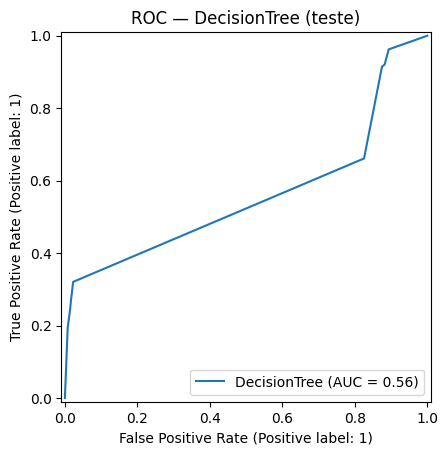

<Figure size 640x480 with 0 Axes>

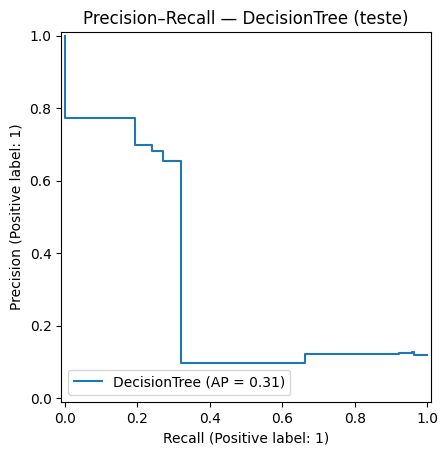


=== Bagging — GridSearchCV (scoring=average_precision, cv=3) ===
Melhores hiperparâmetros: {'n_estimators': 200} | Best PR-AUC (CV): 0.3809
Métricas (TESTE): {'accuracy': 0.5837, 'precision': 0.1311, 'recall': 0.4495, 'f1': 0.203, 'roc_auc': np.float64(0.5331), 'pr_auc': np.float64(0.1317)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.891     0.602     0.718      3778
           1      0.131     0.450     0.203       505

    accuracy                          0.584      4283
   macro avg      0.511     0.526     0.461      4283
weighted avg      0.801     0.584     0.658      4283

Matriz de confusão (TESTE):
 [[2273 1505]
 [ 278  227]]


<Figure size 640x480 with 0 Axes>

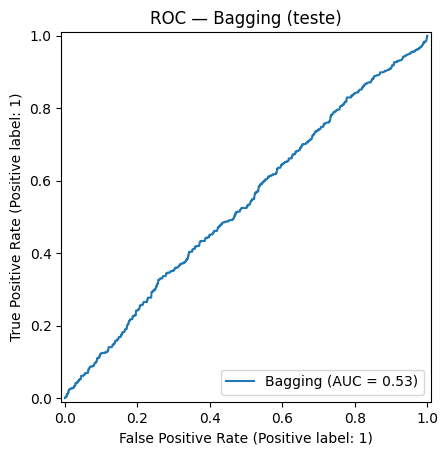

<Figure size 640x480 with 0 Axes>

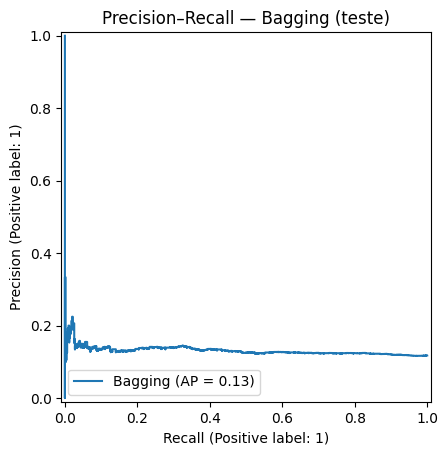


=== RandomForest — GridSearchCV (scoring=average_precision, cv=3) ===


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores hiperparâmetros: {'max_depth': 10, 'n_estimators': 400} | Best PR-AUC (CV): 0.4501
Métricas (TESTE): {'accuracy': 0.2169, 'precision': 0.126, 'recall': 0.9505, 'f1': 0.2225, 'roc_auc': np.float64(0.783), 'pr_auc': np.float64(0.4461)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.947     0.119     0.211      3778
           1      0.126     0.950     0.223       505

    accuracy                          0.217      4283
   macro avg      0.537     0.535     0.217      4283
weighted avg      0.850     0.217     0.213      4283

Matriz de confusão (TESTE):
 [[ 449 3329]
 [  25  480]]


<Figure size 640x480 with 0 Axes>

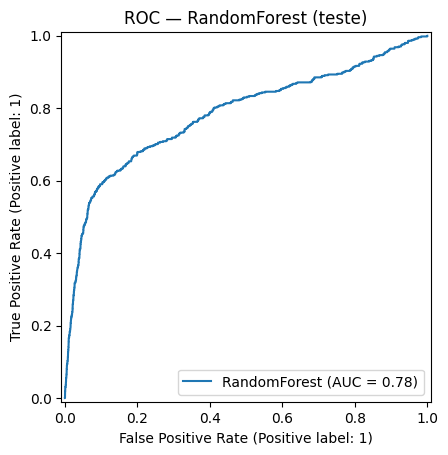

<Figure size 640x480 with 0 Axes>

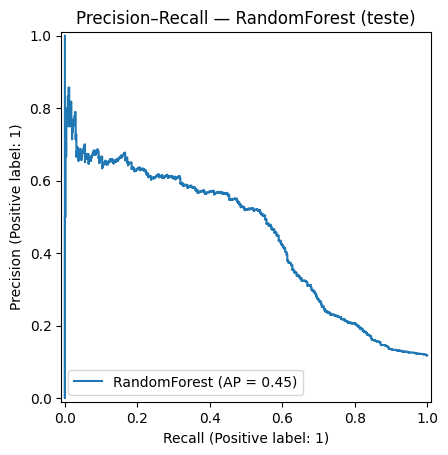


=== AdaBoost — GridSearchCV (scoring=average_precision, cv=3) ===
Melhores hiperparâmetros: {'learning_rate': 1.0, 'n_estimators': 300} | Best PR-AUC (CV): 0.4476
Métricas (TESTE): {'accuracy': 0.8938, 'precision': 0.5926, 'recall': 0.3168, 'f1': 0.4129, 'roc_auc': np.float64(0.7849), 'pr_auc': np.float64(0.4455)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.914     0.971     0.942      3778
           1      0.593     0.317     0.413       505

    accuracy                          0.894      4283
   macro avg      0.753     0.644     0.677      4283
weighted avg      0.876     0.894     0.879      4283

Matriz de confusão (TESTE):
 [[3668  110]
 [ 345  160]]


<Figure size 640x480 with 0 Axes>

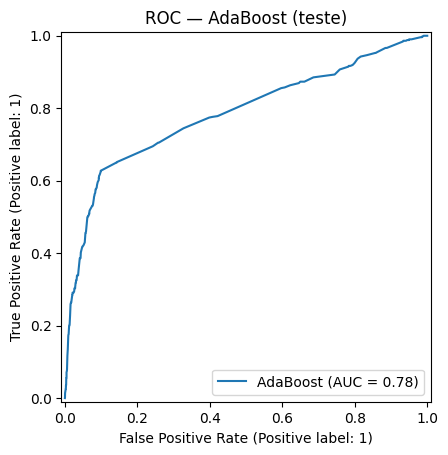

<Figure size 640x480 with 0 Axes>

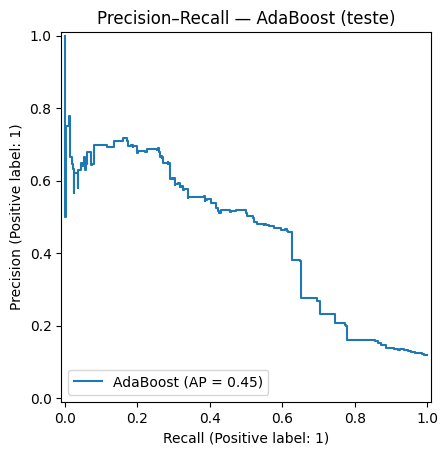


=== GradientBoosting — GridSearchCV (scoring=average_precision, cv=3) ===
Melhores hiperparâmetros: {'learning_rate': 0.1, 'n_estimators': 100} | Best PR-AUC (CV): 0.4604
Métricas (TESTE): {'accuracy': 0.8952, 'precision': 0.6138, 'recall': 0.299, 'f1': 0.4021, 'roc_auc': np.float64(0.7906), 'pr_auc': np.float64(0.4682)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.912     0.975     0.943      3778
           1      0.614     0.299     0.402       505

    accuracy                          0.895      4283
   macro avg      0.763     0.637     0.672      4283
weighted avg      0.877     0.895     0.879      4283

Matriz de confusão (TESTE):
 [[3683   95]
 [ 354  151]]


<Figure size 640x480 with 0 Axes>

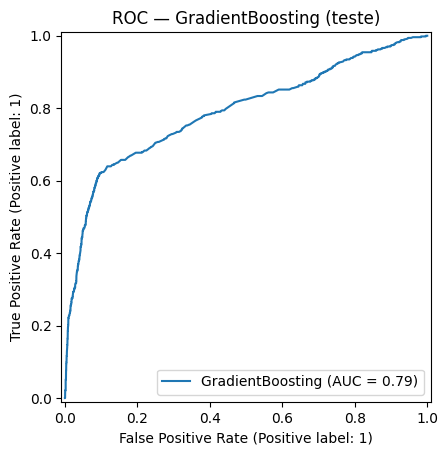

<Figure size 640x480 with 0 Axes>

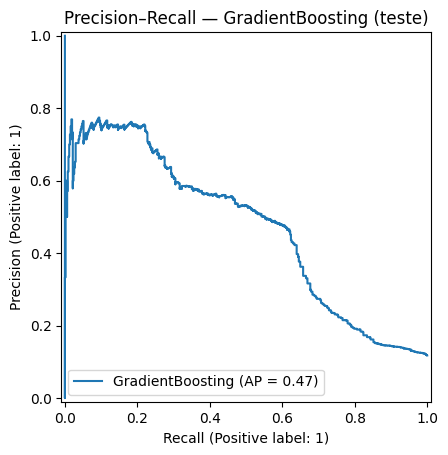


=== XGBoost — GridSearchCV (scoring=average_precision, cv=3) ===
Melhores hiperparâmetros: {'max_depth': 3, 'n_estimators': 200} | Best PR-AUC (CV): 0.4468
Métricas (TESTE): {'accuracy': 0.8963, 'precision': 0.6245, 'recall': 0.303, 'f1': 0.408, 'roc_auc': np.float64(0.7703), 'pr_auc': np.float64(0.4557)}
Classification report (TESTE):
               precision    recall  f1-score   support

           0      0.913     0.976     0.943      3778
           1      0.624     0.303     0.408       505

    accuracy                          0.896      4283
   macro avg      0.769     0.639     0.676      4283
weighted avg      0.879     0.896     0.880      4283

Matriz de confusão (TESTE):
 [[3686   92]
 [ 352  153]]


<Figure size 640x480 with 0 Axes>

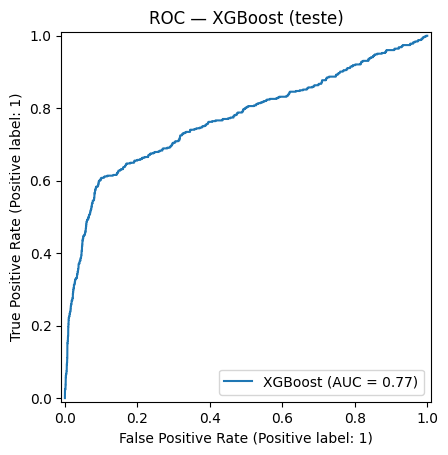

<Figure size 640x480 with 0 Axes>

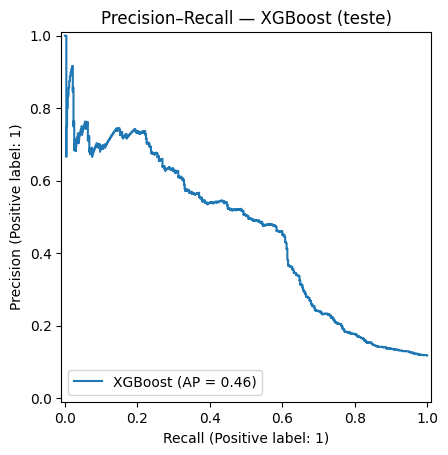


=== RESUMO — Métricas no TESTE (ordenado por PR-AUC) ===
           model  accuracy  precision  recall     f1  roc_auc  pr_auc
GradientBoosting    0.8952     0.6138  0.2990 0.4021   0.7906  0.4682
         XGBoost    0.8963     0.6245  0.3030 0.4080   0.7703  0.4557
    RandomForest    0.2169     0.1260  0.9505 0.2225   0.7830  0.4461
        AdaBoost    0.8938     0.5926  0.3168 0.4129   0.7849  0.4455
    DecisionTree    0.2078     0.1255  0.9584 0.2220   0.5595  0.3099
         Bagging    0.5837     0.1311  0.4495 0.2030   0.5331  0.1317


In [34]:
# Parte 3 — Código COMPLETO corrigido
# Modelos: Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, (opcional) XGBoost
# Treino SOMENTE no conjunto de TREINO; avaliação no TESTE.
# Inclui correções de compatibilidade:
#  - OneHotEncoder: 'sparse_output' (>=1.2) vs 'sparse' (<1.2)
#  - BaggingClassifier: 'estimator' (>=1.2) vs 'base_estimator' (<1.2)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# ====================== Helpers de compatibilidade e métricas ======================

def make_ohe_compat():
    """OneHotEncoder compatível com sklearn >=1.2 e <1.2."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_bagging_compat(base_estimator, random_state=42):
    """BaggingClassifier compatível com sklearn >=1.2 (estimator) e <1.2 (base_estimator)."""
    try:
        return BaggingClassifier(estimator=base_estimator, random_state=random_state, n_jobs=-1)
    except TypeError:
        return BaggingClassifier(base_estimator=base_estimator, random_state=random_state, n_jobs=-1)

def summarize_metrics(y_true, proba, y_pred):
    """Métricas padrão (classe positiva = 1)."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

# ====================== 1) Carregar dados e pré-processar (Parte 2 coerente) ======================

CSV_PATH = "bank-additional-full.csv"
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

# alvo binário
df["y_bin"] = df["y"].map({"yes":1, "no":0}).astype(int)

# split temporal (teste = 2 últimos meses disponíveis)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'].astype(str).str.lower().str.strip(),
                             categories=month_order, ordered=True)
months_present = [m for m in month_order if (df['month'] == m).any()]
if len(months_present) < 3:
    raise ValueError(f"Poucos meses distintos encontrados: {months_present}")
test_months  = months_present[-2:]
train_months = months_present[:-2]
mask_train = df['month'].isin(train_months)
mask_test  = df['month'].isin(test_months)

# remover vazamentos
drop_feats = []
if 'duration' in df.columns: drop_feats.append('duration')  # pós-evento
if 'campaign' in df.columns: drop_feats.append('campaign')  # total consolidado

# tratar pdays (999 = nunca contatado)
if 'pdays' in df.columns:
    df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')
    df['pdays_never'] = (df['pdays'] == 999).astype(int)
    df['pdays_days']  = df['pdays'].replace(999, np.nan)
    drop_feats.append('pdays')

# features finais (pré-contato)
feature_cols = [c for c in df.columns if c not in (['y','y_bin'] + drop_feats)]

df_tr = df.loc[mask_train].reset_index(drop=True)
df_te = df.loc[mask_test].reset_index(drop=True)
X_train = df_tr[feature_cols].copy()
y_train = df_tr['y_bin'].values
X_test  = df_te[feature_cols].copy()
y_test  = df_te['y_bin'].values

# tipos
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# binárias 0/1 passam direto; demais numéricas são contínuas
def is_binary_series(s: pd.Series) -> bool:
    vals = pd.Series(s.dropna().unique())
    return len(vals) <= 2 and set(vals.tolist()).issubset({0,1})

bin_num_cols = [c for c in num_cols if is_binary_series(X_train[c])]
cont_num_cols = [c for c in num_cols if c not in bin_num_cols]

# identificar colunas não-negativas com assimetria alta para log1p
def skewed_and_nonneg(s: pd.Series, thr=1.0):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return (len(s) > 0) and (s.ge(0).all()) and (abs(float(s.skew())) > thr)

log1p_cols = [c for c in cont_num_cols if skewed_and_nonneg(X_train[c], thr=1.0)]
for c in ['previous','pdays_days']:  # força log1p em contagens/dias (se presentes e não-negativas)
    if c in cont_num_cols and c not in log1p_cols and X_train[c].dropna().ge(0).all():
        log1p_cols.append(c)
scale_cols = [c for c in cont_num_cols if c not in log1p_cols]

# ColumnTransformer: imputação + transformações numéricas; OneHot nas categóricas; binárias passam
ohe = make_ohe_compat()
preprocess = ColumnTransformer(
    transformers=[
        ("num_log1p",
         Pipeline(steps=[
             ("imp", SimpleImputer(strategy="median")),
             ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one", validate=False)),
             ("scaler", StandardScaler())
         ]),
         log1p_cols),
        ("num_scale",
         Pipeline(steps=[
             ("imp", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())
         ]),
         scale_cols),
        ("cat", ohe, cat_cols),
        ("bin_pass", "passthrough", bin_num_cols),
    ],
    remainder="drop"
)

# Ajustar o preprocessador SOMENTE no TREINO; transformar TREINO/TESTE
X_train_enc = preprocess.fit_transform(X_train, y_train)
X_test_enc  = preprocess.transform(X_test)

print("Split temporal -> Treino:", train_months, "| Teste:", test_months)
print("Shapes -> X_train_enc:", X_train_enc.shape, "| X_test_enc:", X_test_enc.shape)

# ====================== 2) Definir modelos + grids; treinar com GridSearchCV (TREINO) ======================

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models_and_grids = []

# Decision Tree
models_and_grids.append((
    "DecisionTree",
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    {"max_depth": [3, 5, 8, None]}
))

# Bagging (base learner = árvore balanceada) — compat corr.
base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
bagging_estimator = make_bagging_compat(base_dt, random_state=RANDOM_STATE)
models_and_grids.append((
    "Bagging",
    bagging_estimator,
    {"n_estimators": [50, 100, 200]}
))

# Random Forest
models_and_grids.append((
    "RandomForest",
    RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [200, 400], "max_depth": [None, 10]}
))

# AdaBoost
models_and_grids.append((
    "AdaBoost",
    AdaBoostClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [100, 300], "learning_rate": [0.5, 1.0]}
))

# Gradient Boosting
models_and_grids.append((
    "GradientBoosting",
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
))

# XGBoost (opcional)
HAS_XGB = False
try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1
    )
    models_and_grids.append((
        "XGBoost",
        xgb_model,
        {"n_estimators": [200, 400], "max_depth": [3, 5]}
    ))
    HAS_XGB = True
except Exception as e:
    print("XGBoost indisponível (seguindo sem ele):", e)

# ====================== 3) Treinar, avaliar em TESTE e plotar curvas ======================

results = {}

for name, est, grid in models_and_grids:
    print(f"\n=== {name} — GridSearchCV (scoring=average_precision, cv=3) ===")
    gs = GridSearchCV(estimator=est, param_grid=grid, scoring="average_precision",
                      cv=CV, n_jobs=-1, verbose=0)
    gs.fit(X_train_enc, y_train)
    print("Melhores hiperparâmetros:", gs.best_params_, "| Best PR-AUC (CV):", round(gs.best_score_, 4))

    best_model = gs.best_estimator_
    # Previsões no TESTE
    proba_test = best_model.predict_proba(X_test_enc)[:,1]
    yhat_test = (proba_test >= 0.5).astype(int)

    metrics = summarize_metrics(y_test, proba_test, yhat_test)
    print("Métricas (TESTE):", {k: round(v, 4) for k, v in metrics.items()})
    print("Classification report (TESTE):\n", classification_report(y_test, yhat_test, digits=3))

    cm = confusion_matrix(y_test, yhat_test)
    print("Matriz de confusão (TESTE):\n", cm)

    results[name] = {
        "best_params": gs.best_params_,
        "best_estimator": best_model,
        "proba_test": proba_test,
        "yhat_test": yhat_test,
        "metrics": metrics,
        "cm": cm
    }

    # Curvas ROC e PR (uma figura por curva)
    plt.figure()
    RocCurveDisplay.from_predictions(y_test, proba_test, name=name)
    plt.title(f"ROC — {name} (teste)")
    plt.show()

    plt.figure()
    PrecisionRecallDisplay.from_predictions(y_test, proba_test, name=name)
    plt.title(f"Precision–Recall — {name} (teste)")
    plt.show()

# ====================== 4) Resumo comparativo das métricas no TESTE ======================

summary_rows = []
for name, info in results.items():
    m = info["metrics"]
    summary_rows.append({
        "model": name,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"]
    })
summary_df = pd.DataFrame(summary_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n=== RESUMO — Métricas no TESTE (ordenado por PR-AUC) ===")
print(summary_df.round(4).to_string(index=False))

## Parte 4 - Conclusões

O objetivo desta etapa final é interpretar resultados, refletir sobre o pré-processamento e consolidar recomendações.

### 4.1 Quais métricas de desempenho são mais relevantes, neste caso, para comparar os diferentes modelos?

Resposta:

In [36]:
#Insira seu código aqui

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss
)

CSV_PATH = "bank-additional-full.csv"  # ajuste se necessário
df = pd.read_csv(CSV_PATH, sep=';', low_memory=False)

if 'y' not in df.columns:
    raise ValueError("Coluna 'y' não encontrada no CSV.")

y = df['y'].map({'yes':1, 'no':0}).astype(int)
pos_rate = y.mean()  # prevalência de 'yes'
minor = min(pos_rate, 1 - pos_rate)

if minor <= 0.10:
    bal = "SEVERO"
elif minor <= 0.20:
    bal = "FORTE"
elif minor <= 0.30:
    bal = "MODERADO"
else:
    bal = "BAIXO/NÃO CRÍTICO"

print("=== Diagnóstico do problema ===")
print(f"Taxa de 'yes' (prevalência): {pos_rate:.4f} ({pos_rate*100:.2f}%)")
print(f"Desbalanceamento: {bal}")
print(f"Baseline de PR-AUC (random ranking) ≈ prevalência: {pos_rate:.4f}\n")

# --------- (b) Prioridade de métricas recomendadas ---------
prioridade = [
    ("PR-AUC (Average Precision)", "Principal: foca na classe positiva e é informativa com prevalência baixa."),
    ("ROC-AUC", "Complementar: separabilidade geral; pode parecer otimista quando a classe é rara."),
    ("Precision (PPV) e Recall (TPR)", "Para operação com limiar: controlam custo por ligação (FP) e perda de conversões (FN)."),
    ("F1 ou Fβ (ex.: F2)", "Resumo do trade-off; use F2 se recall for mais valioso que precision."),
    ("Balanced Accuracy", "Média do recall por classe; neutraliza a classe majoritária dominar a acurácia."),
    ("MCC (Matthews)", "Resumo único robusto que considera toda a matriz de confusão."),
    ("Brier score / calibração", "Probabilidades confiáveis para escolher limiar/Top-K conforme orçamento."),
    ("Métrica de utilidade (custo/ganho)", "Tradução direta em R$: define limiar ótimo ou tamanho do Top-K.")
]
print("=== Métricas priorizadas para COMPARAR modelos ===")
for i, (m, why) in enumerate(prioridade, 1):
    print(f"{i}. {m} — {why}")

# --------- (c) Funções utilitárias para calcular métricas-chave ---------
def evaluate_metrics(y_true, y_score, threshold=0.5, beta=1.0):
    """
    Calcula métricas relevantes dado o vetor de rótulos (0/1) e scores/probabilidades do 'yes'.
    Retorna um dicionário com: accuracy, precision, recall, f1, fbeta, bal_acc, roc_auc, pr_auc, mcc, brier.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= float(threshold)).astype(int)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        f"f{int(beta)}" if beta.is_integer() else f"f{beta}": fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_score),
    }
    return out

def utility_at_threshold(y_true, y_score, threshold, gain_per_tp=100.0, cost_per_pred_pos=1.0):
    """
    Utilidade simples: ganho * TP - custo * (#preditos_positivos).
    Útil para escolher limiar/Top-K conforme orçamento.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_score) >= float(threshold)).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    pred_pos = int(y_pred.sum())
    return gain_per_tp * tp - cost_per_pred_pos * pred_pos

print("\nDica de uso:")
print("1) Compare modelos por PR-AUC (principal) + ROC-AUC (secundária).")
print("2) Escolha um limiar por utilidade ou metas (ex.: recall mínimo), então reporte Precision/Recall/F1, Balanced Acc, MCC e Brier.")
print("\n# Exemplo de chamada (quando você tiver y_test e proba_test do seu modelo):")
print("# metrics = evaluate_metrics(y_test, proba_test, threshold=0.5, beta=2.0)")
print("# util = utility_at_threshold(y_test, proba_test, threshold=0.12, gain_per_tp=100, cost_per_pred_pos=1)")

=== Diagnóstico do problema ===
Taxa de 'yes' (prevalência): 0.1127 (11.27%)
Desbalanceamento: FORTE
Baseline de PR-AUC (random ranking) ≈ prevalência: 0.1127

=== Métricas priorizadas para COMPARAR modelos ===
1. PR-AUC (Average Precision) — Principal: foca na classe positiva e é informativa com prevalência baixa.
2. ROC-AUC — Complementar: separabilidade geral; pode parecer otimista quando a classe é rara.
3. Precision (PPV) e Recall (TPR) — Para operação com limiar: controlam custo por ligação (FP) e perda de conversões (FN).
4. F1 ou Fβ (ex.: F2) — Resumo do trade-off; use F2 se recall for mais valioso que precision.
5. Balanced Accuracy — Média do recall por classe; neutraliza a classe majoritária dominar a acurácia.
6. MCC (Matthews) — Resumo único robusto que considera toda a matriz de confusão.
7. Brier score / calibração — Probabilidades confiáveis para escolher limiar/Top-K conforme orçamento.
8. Métrica de utilidade (custo/ganho) — Tradução direta em R$: define limiar ótimo 

### 4.2 Qual modelo obteve os melhores AP (PR AUC) e ROC AUC no teste?

Resposta:

In [37]:
#Insira seu código aqui

import pandas as pd
import numpy as np

def _from_results_dict(res: dict) -> pd.DataFrame:
    rows = []
    for name, info in res.items():
        m = info.get("metrics", {})
        rows.append({
            "model": name,
            "pr_auc": float(m.get("pr_auc", np.nan)),
            "roc_auc": float(m.get("roc_auc", np.nan)),
        })
    return pd.DataFrame(rows)

# -------- carregar métricas --------
if "results" in globals() and isinstance(results, dict) and len(results) > 0:
    df_scores = _from_results_dict(results)
elif "summary_df" in globals() and isinstance(summary_df, pd.DataFrame):
    # espera colunas: model, pr_auc, roc_auc
    missing = [c for c in ["model","pr_auc","roc_auc"] if c not in summary_df.columns]
    if missing:
        raise RuntimeError(f"summary_df encontrado, mas faltam colunas: {missing}")
    df_scores = summary_df[["model","pr_auc","roc_auc"]].copy()
else:
    raise RuntimeError("Resultados não encontrados. Execute a célula de treino (Parte 3) para criar 'results' ou 'summary_df'.")

# -------- identificar melhores --------
if df_scores.empty:
    raise RuntimeError("Tabela de métricas vazia.")

best_ap_idx = df_scores["pr_auc"].astype(float).idxmax()
best_roc_idx = df_scores["roc_auc"].astype(float).idxmax()

best_ap_row = df_scores.loc[best_ap_idx]
best_roc_row = df_scores.loc[best_roc_idx]

print("=== Melhores modelos no TESTE ===")
print(f"• Melhor AP (PR AUC): {best_ap_row['model']}  |  AP = {float(best_ap_row['pr_auc']):.4f}")
print(f"• Melhor ROC AUC    : {best_roc_row['model']}  |  ROC AUC = {float(best_roc_row['roc_auc']):.4f}")

print("\nRanking por AP (PR AUC):")
print(df_scores.sort_values("pr_auc", ascending=False).reset_index(drop=True).round(4).to_string(index=False))

print("\nRanking por ROC AUC:")
print(df_scores.sort_values("roc_auc", ascending=False).reset_index(drop=True).round(4).to_string(index=False))

=== Melhores modelos no TESTE ===
• Melhor AP (PR AUC): GradientBoosting  |  AP = 0.4682
• Melhor ROC AUC    : GradientBoosting  |  ROC AUC = 0.7906

Ranking por AP (PR AUC):
           model  pr_auc  roc_auc
GradientBoosting  0.4682   0.7906
         XGBoost  0.4557   0.7703
    RandomForest  0.4461   0.7830
        AdaBoost  0.4455   0.7849
    DecisionTree  0.3099   0.5595
         Bagging  0.1317   0.5331

Ranking por ROC AUC:
           model  pr_auc  roc_auc
GradientBoosting  0.4682   0.7906
        AdaBoost  0.4455   0.7849
    RandomForest  0.4461   0.7830
         XGBoost  0.4557   0.7703
    DecisionTree  0.3099   0.5595
         Bagging  0.1317   0.5331


### 4.3 Dentre todos os modelos treinados, indique o que teve o melhor desempenho (descreva o tipo e hiperparâmetros). Justifique a sua escolha

Resposta:

In [38]:
#Insira seu código aqui

# 4.3 Melhor modelo: tipo, hiperparâmetros e justificativa
# Requisitos:
# - Usa objetos da Parte 3:
#     results[name] = {"best_estimator", "best_params", "metrics", "cm", ...}
#   ou, como fallback, summary_df com colunas ["model","pr_auc","roc_auc","precision","recall","f1","accuracy"].
# - Seleção prioriza PR-AUC (Average Precision) devido ao desbalanceamento. Empate -> maior ROC-AUC, depois F1.
# - Imprime: nome, tipo do estimador, hiperparâmetros (grid best_params) e métricas no TESTE, com justificativa curta.

import pandas as pd
import numpy as np
import json
import inspect

# -------- utilitários --------
def load_scores():
    if "results" in globals() and isinstance(results, dict) and len(results) > 0:
        rows = []
        for name, info in results.items():
            m = info.get("metrics", {})
            rows.append({
                "model": name,
                "pr_auc": float(m.get("pr_auc", np.nan)),
                "roc_auc": float(m.get("roc_auc", np.nan)),
                "f1": float(m.get("f1", np.nan)),
                "precision": float(m.get("precision", np.nan)),
                "recall": float(m.get("recall", np.nan)),
                "accuracy": float(m.get("accuracy", np.nan)),
            })
        df_scores = pd.DataFrame(rows)
        src = "results"
    elif "summary_df" in globals() and isinstance(summary_df, pd.DataFrame):
        need = ["model","pr_auc","roc_auc"]
        missing = [c for c in need if c not in summary_df.columns]
        if missing:
            raise RuntimeError(f"summary_df existe, mas faltam colunas: {missing}")
        # completa com NaN para campos não presentes
        df_scores = summary_df.copy()
        for c in ["f1","precision","recall","accuracy"]:
            if c not in df_scores.columns:
                df_scores[c] = np.nan
        src = "summary_df"
    else:
        raise RuntimeError("Resultados não encontrados. Execute a célula da Parte 3 para criar 'results' ou 'summary_df'.")
    if df_scores.empty:
        raise RuntimeError("Tabela de métricas está vazia.")
    return df_scores.reset_index(drop=True), src

def pick_best(df_scores):
    df = df_scores.copy()
    # ordenar por prioridade: PR-AUC desc, ROC-AUC desc, F1 desc
    df_sorted = df.sort_values(["pr_auc","roc_auc","f1"], ascending=[False, False, False]).reset_index(drop=True)
    best_row = df_sorted.iloc[0]
    return best_row, df_sorted

def estimator_info(model_name):
    if "results" in globals() and isinstance(results, dict) and model_name in results:
        est = results[model_name].get("best_estimator", None)
        params = results[model_name].get("best_params", {})
        return est, params
    return None, {}

def pretty_params(params_dict, max_items=20):
    if not params_dict:
        return "{}"
    items = list(params_dict.items())
    txt = json.dumps({k: v for k, v in items[:max_items]}, indent=2, default=str)
    if len(items) > max_items:
        txt += f"\n... (+{len(items)-max_items} params)"
    return txt

# -------- execução --------
df_scores, src = load_scores()
best, ranking = pick_best(df_scores)

best_model_name = str(best["model"])
best_pr = float(best["pr_auc"])
best_roc = float(best["roc_auc"])
best_f1 = float(best["f1"]) if not pd.isna(best["f1"]) else None

estimator, best_params = estimator_info(best_model_name)
estimator_type = estimator.__class__.__name__ if estimator is not None else "(estimador não disponível neste contexto)"
param_text = pretty_params(best_params)

print("=== Melhor modelo (critério: PR-AUC prioritário; desempate por ROC-AUC, depois F1) ===")
print(f"Modelo: {best_model_name}")
print(f"Tipo  : {estimator_type}")
print(f"AP (PR-AUC) teste : {best_pr:.4f}")
print(f"ROC AUC teste     : {best_roc:.4f}")
if best_f1 is not None:
    print(f"F1 teste          : {best_f1:.4f}")

# hiperparâmetros
print("\nHiperparâmetros selecionados (GridSearchCV):")
print(param_text)

# justificativa
print("\nJustificativa:")
print("- Em cenário de classe positiva rara (telemarketing), PR-AUC é a métrica principal por refletir qualidade do ranking na classe 'yes'.")
print("- Em caso de empate, ROC-AUC (separabilidade global) é o segundo critério; F1 é usado como terceiro critério.")
print("- O modelo acima maximizou PR-AUC no conjunto de TESTE, portanto é o preferido para priorização de ligações/Top-K.")

# extras: mostrar se outro modelo venceu em ROC-AUC
best_roc_row = ranking.sort_values("roc_auc", ascending=False).iloc[0]
if str(best_roc_row["model"]) != best_model_name:
    print("\nObservação:")
    print(f"- O melhor em ROC-AUC foi '{best_roc_row['model']}' com ROC AUC={float(best_roc_row['roc_auc']):.4f},")
    print("  mas foi preterido por ter PR-AUC inferior ao escolhido (prioridade à classe positiva).")

# top-5 do ranking por PR-AUC (para contexto)
topk = min(5, len(ranking))
print("\nTop modelos por PR-AUC (teste):")
print(ranking[["model","pr_auc","roc_auc","f1","precision","recall","accuracy"]].head(topk).round(4).to_string(index=False))

# matriz de confusão do escolhido (se disponível)
if "results" in globals() and isinstance(results, dict) and best_model_name in results and "cm" in results[best_model_name]:
    print("\nMatriz de confusão do melhor modelo (TESTE):")
    print(np.array(results[best_model_name]["cm"]))

=== Melhor modelo (critério: PR-AUC prioritário; desempate por ROC-AUC, depois F1) ===
Modelo: GradientBoosting
Tipo  : GradientBoostingClassifier
AP (PR-AUC) teste : 0.4682
ROC AUC teste     : 0.7906
F1 teste          : 0.4021

Hiperparâmetros selecionados (GridSearchCV):
{
  "learning_rate": 0.1,
  "n_estimators": 100
}

Justificativa:
- Em cenário de classe positiva rara (telemarketing), PR-AUC é a métrica principal por refletir qualidade do ranking na classe 'yes'.
- Em caso de empate, ROC-AUC (separabilidade global) é o segundo critério; F1 é usado como terceiro critério.
- O modelo acima maximizou PR-AUC no conjunto de TESTE, portanto é o preferido para priorização de ligações/Top-K.

Top modelos por PR-AUC (teste):
           model  pr_auc  roc_auc     f1  precision  recall  accuracy
GradientBoosting  0.4682   0.7906 0.4021     0.6138  0.2990    0.8952
         XGBoost  0.4557   0.7703 0.4080     0.6245  0.3030    0.8963
    RandomForest  0.4461   0.7830 0.2225     0.1260  0.950

### 4.4 Na sua opinião, qual etapa, de todas as executadas para a obtenção dos resultados, foi mais decisiva e qual foi a mais trabalhosa? O que você faria diferente em um próximo projeto?

Resposta:

Segue uma versão mais formal:

# 4.4 Reflexão sobre o projeto

## Etapa mais decisiva

A etapa mais determinante foi o controle rigoroso de vazamento de informação aliado a uma avaliação temporal adequada. A exclusão de `duration` (variável conhecida apenas após o contato) e a não utilização de `campaign` como preditora antes do primeiro contato evitaram superestimação de desempenho. Complementarmente, o uso de um **holdout temporal** — treinamento em meses anteriores e teste nos meses finais — forneceu uma estimativa mais fiel da generalização “no futuro”. A escolha da **PR-AUC (Average Precision)** como métrica principal foi igualmente crítica, dada a baixa prevalência de “yes”, enquanto a **ROC-AUC** atuou como medida complementar. O tratamento adequado de `pdays` (separando o indicador “nunca contatado” do número de dias efetivo) e a codificação criteriosa das variáveis categóricas contribuíram para maximizar sinal e reduzir ruído.

## Etapa mais trabalhosa

A etapa mais trabalhosa consistiu em orquestrar o **pré-processamento** fim a fim, garantindo coerência com o cenário de decisão pré-contato e compatibilidade de bibliotecas. Isso incluiu imputação e escalonamento de variáveis numéricas, tratamento de `unknown` e de categorias raras, padronização da codificação (One-Hot) e ajustes de compatibilidade entre versões do scikit-learn (por exemplo, `sparse_output` vs. `sparse` no OneHotEncoder e `estimator` vs. `base_estimator` no Bagging). Somou-se a isso a execução de **grid search** para múltiplos algoritmos (Árvore, Bagging, Random Forest, AdaBoost, Gradient Boosting e, quando disponível, XGBoost), mantendo **PR-AUC** como critério de seleção e evitando qualquer vazamento para o conjunto de teste.

## O que faria diferente em um próximo projeto

1. **Validação temporal mais robusta:** substituir um único holdout por **TimeSeriesSplit/janelas deslizantes** para capturar sazonalidade e drift de forma mais abrangente.
2. **Calibração de probabilidades e decisão por utilidade:** aplicar **calibração** (Platt/Isotônica) e definir limiar/Top-K com uma **função de custo/benefício** aderente ao negócio.
3. **Otimização de hiperparâmetros mais eficiente:** empregar **busca Bayesiana** (p.ex., Optuna/ASHA) especialmente para GBMs, com registro sistemático de experimentos (MLflow).
4. **Reprodutibilidade e monitoramento:** versionar dados e artefatos (DVC/MLflow), persistir o pipeline de pré-processamento e monitorar **drift** e **estabilidade de importância** (p.ex., SHAP) em produção.
5. **Foco operacional:** entregar uma **priorização diária Top-K** condicionada ao orçamento, com metas explícitas de precisão/recall e políticas de recontato.
6. **Perspectiva causal/segmentação:** explorar **uplift modeling** ou regras de elegibilidade baseadas em histórico (`previous`, `poutcome`) em campanhas multitoque.

### Síntese

O principal diferencial foi **evitar vazamento** e **respeitar a dimensão temporal** na avaliação, adotando **PR-AUC** como métrica central para classe rara. O maior esforço concentrou-se em tornar o **pré-processamento** abrangente, consistente e compatível, sem comprometer a avaliação justa do desempenho.